# 107_03 — Convergencia de las cadenas MCMC · Escenario C-1 · **barrido en $M$**

Paso **3a** del ciclo. Este notebook **sólo diagnostica las cadenas**: no
predice, no evalúa y no toca el bloque de prueba. Si algo aquí falla, los
números de `107_04` no significan nada, y por eso son notebooks separados.

| Estadístico | Referencia | Lectura |
|---|---|---|
| ESS | Geyer (1992) | $\gtrsim 400$ ideal, $>100$ aceptable |
| Geweke $z$ | test $z$ entre segmentos | $\lvert z\rvert < 2$ ⇒ no se rechaza |
| $\hat R$ | Gelman-Rubin | $< 1.1$ ⇒ convergencia |

El escenario **no cambia nada de este notebook**: sólo diagnostica cadenas. Lo único propio del C-1 es §6.1.



## 1. Imports, rutas y carga de artefactos

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
    cargar_escenario, cargar_fpca,
)
from model_psbp_fd.utils.quadrature import pesos_trapezoidales
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor
from model_psbp_fd.fit import (
    tabla_diagnosticos, resumen_convergencia, diagnostico_variable,
    extraer_traza_variable, matriz_pip, contraste_con_verdad,
)
from model_psbp_fd.graphics import (
    plot_global_components, plot_active_clusters,
    plot_convergence_bj, plot_convergence_pj,
)
from model_psbp_fd.utils import get_project_root, normalizar_trazas_mat

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [ ]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] 
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario_107", 1, 1
M_FPCA_LIST = (1, 2, 3, 4)

SALTAR_M_SIN_TRAZAS = True

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."
assert all(m >= 1 for m in M_FPCA_LIST), "M debe ser >= 1."

EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    """Convención vigente desde la corrida 30: M viaja en el ID."""
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M = {M: rutas(M) for M in M_FPCA_LIST}

# Las salidas que CRUZAN los M no caben en el directorio de ninguno de ellos:
# van a un directorio propio del barrido, hermano de los de cada punto.
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas (§8) : {PATH_BARRIDO}   (archivos 80-83)")

barrido en M : [3, 4, 5, 6]
  M=3  ->  escenario_107_1_r01_m03
  M=4  ->  escenario_107_1_r01_m04
  M=5  ->  escenario_107_1_r01_m05
  M=6  ->  escenario_107_1_r01_m06
salidas cruzadas (§8) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_107_1_r01_barrido_M   (archivos 80-83)


In [ ]:
# Carga de artefactos por M. `EST[M]` es el estado completo de ese punto del
# barrido; todo lo que sigue lo consume por índice, nunca por variable global.
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 107_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    hp_json     = cargar_hiperparametros(P)
    P["trazas"] = P["out_artefact"].parent / hp_json.get("trazas_en", P["out_artefact"].name)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)

    # El ID declara M; el manifest lo determina. Si discrepan, el directorio
    # está mal nombrado y todo lo demás sería una comparación entre otra cosa.
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes. El directorio no corresponde a este "
        "punto del barrido.")
    assert len(hp_json["hyperparams_list"]) == n_components, \
        f"[M={M}] n_components discrepa entre manifest e hyperparameters.json."

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "cov_por_componente": [list(manifest["cov_por_componente"][str(k)]) for k in range(n_components)],
        "n_lags": int(manifest["n_lags"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 107_01 primero."

print(f"{'M':>3}  {'comp':>4}  {'cadenas':>7}  {'covariables':>11}  seed_base")
print(f"{'-'*3}  {'-'*4}  {'-'*7}  {'-'*11}  {'-'*9}")
for M, e in EST.items():
    print(f"{M:>3}  {e['n_components']:>4}  {e['n_iter']:>7}  "
          f"{len(e['cov_names']):>11}  {e['hp_json']['seed_base']}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

_cfgs = {M: (e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"], e["n_iter"])
         for M, e in EST.items()}
if len(set(_cfgs.values())) > 1:
    print("\n! La configuración MCMC NO es la misma en todos los M:")
    for M, c in _cfgs.items():
        print(f"    M={M}: nsim/N/burn/cadenas = {c}")
    print("  Las diferencias entre M mezclarían efecto de M con efecto de ajuste.")
else:
    print(f"\nOK misma configuración MCMC en todos los M: "
          f"nsim/N/burn/cadenas = {next(iter(_cfgs.values()))}")

  M  comp  cadenas  covariables  seed_base
---  ----  -------  -----------  ---------
  3     3        2            6  41232
  4     4        2            8  41232
  ! M=5 saltado: sin datasets_manifest.json - falta correr 107_01
  ! M=6 saltado: sin datasets_manifest.json - falta correr 107_01

OK misma configuración MCMC en todos los M: nsim/N/burn/cadenas = (3000, 30, 1000, 2)


## 2. Lectura de las trazas


In [ ]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]


def ruta_traza(P, fpc_idx: int, chain: int) -> Path:
    return P.get("trazas", P["out_artefact"]) / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path: Path):
    """.mat de psbp_train -> (traces, burn, feature_names)."""
    m = loadmat(str(path))
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in _CLAVES_TRAZA}
    for k in ("muout", "N1out", "Nout"):
        traces[k] = np.asarray(m[k], dtype=np.float64).ravel()
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    """Adaptador trazas MATLAB -> interfaz de `graphics` y del predictor v3."""

    def __init__(self, traces, burn, feature_names):
        # NORMALIZADAS, no crudas: con p = 1 MATLAB colapsa el eje final y
        # betajhout llega (nsim, N). Crudas, tabla_diagnosticos leia shape[-1]
        # = N y diagnosticaba los N ATOMOS como si fueran N covariables, con
        # extraer_traza_variable en su rama 2D -un atomo fijo, sin promediar-,
        # de modo que R-hat media el etiquetado y no la convergencia.
        # Idempotente: con p >= 2 no toca nada.
        self.traces = normalizar_trazas_mat(traces)
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)
        # Se toma del predictor y no de `traces["betajhout"].shape[2]` porque
        # MATLAB descarta las dimensiones singleton finales: con p = 1 (el punto
        # M = 1 del barrido) la traza llega 2D y ese índice no existe.
        self.n_features_ = int(self.predictor_.n_features_)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def predict(self, df, return_std=False):
        return self.predictor_.predict(self._diseno(df), return_std=return_std)

In [ ]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = (f"faltan {len(faltan)} trazas en {P['out_artefact']}: "
               f"{faltan[:3]}{'...' if len(faltan) > 3 else ''}")
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains, meta = {k: {} for k in range(n_comp)}, set()
    print(f"-- M={M} " + "-" * 46)
    for k in range(n_comp):
        fpc = ci[k] + 1
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, fpc, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} chain={c+1}] feature_names del .mat != columnas "
                f"del dataset:\n  mat  = {feat}\n  train= {esperado}")
            mt = ModeloTraza(traces, burn, feat)
            models_chains[k][c] = mt
            meta.add((traces["betajhout"].shape[0],
                      traces["beta0hout"].shape[1], burn))
            print(f"  FPC {fpc}  chain{c+1:02d}  p={mt.n_features_}  "
                  f"N={traces['beta0hout'].shape[1]}  "
                  f"nsim={traces['betajhout'].shape[0]}  burn={burn}")

    assert len(meta) == 1, f"[M={M}] configuraciones MCMC heterogéneas: {meta}."
    nsim, n_atomos, burn = next(iter(meta))
    cfg = e["mcmc_cfg"]
    assert (nsim, n_atomos, burn) == (cfg["nsim"], cfg["N"], cfg["burn"]), (
        f"[M={M}] trazas (nsim={nsim}, N={n_atomos}, burn={burn}) != "
        f"hyperparameters.json ({cfg}).")

    e["models_chains"] = models_chains
    e["n_atomos"] = n_atomos
    e["n_post"] = nsim - burn

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")

print()
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")
for M, e in EST.items():
    print(f"OK M={M}: {e['n_components']} componente(s) x {e['n_iter']} cadena(s) "
          f"· {e['n_post']} draws posteriores c/u -> "
          f"{e['n_post'] * e['n_iter']} por componente")

M_OK = tuple(sorted(EST))       # los M efectivamente disponibles, de aquí en más

-- M=3 ----------------------------------------------
  FPC 1  chain01  p=6  N=30  nsim=3000  burn=1000
  FPC 1  chain02  p=6  N=30  nsim=3000  burn=1000
  FPC 2  chain01  p=6  N=30  nsim=3000  burn=1000
  FPC 2  chain02  p=6  N=30  nsim=3000  burn=1000
  FPC 3  chain01  p=6  N=30  nsim=3000  burn=1000
  FPC 3  chain02  p=6  N=30  nsim=3000  burn=1000
-- M=4 ----------------------------------------------
  FPC 1  chain01  p=8  N=30  nsim=3000  burn=1000
  FPC 1  chain02  p=8  N=30  nsim=3000  burn=1000
  FPC 2  chain01  p=8  N=30  nsim=3000  burn=1000
  FPC 2  chain02  p=8  N=30  nsim=3000  burn=1000
  FPC 3  chain01  p=8  N=30  nsim=3000  burn=1000
  FPC 3  chain02  p=8  N=30  nsim=3000  burn=1000
  FPC 4  chain01  p=8  N=30  nsim=3000  burn=1000
  FPC 4  chain02  p=8  N=30  nsim=3000  burn=1000

OK M=3: 3 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente
OK M=4: 4 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente


## 3. Tabla de diagnósticos

`fit.tabla_diagnosticos` calcula ESS, Geweke y $\hat R$ **sin generar figuras**.
Antes ese cálculo vivía dentro de `plot_convergence_*`, de modo que obtener la
tabla obligaba a dibujar; ahora las figuras de §5 lo consumen del mismo módulo.

Una tabla por $M$, cada una guardada en el directorio de su punto del barrido
con el nombre de siempre (`40_diagnosticos_mcmc.csv`). La comparación entre $M$
va en §8.

In [ ]:
for M in M_OK:
    e = EST[M]
    diag_df = tabla_diagnosticos(e["models_chains"], e["burn"],
                                 component_idx=e["component_idx"],
                                 claves=("betajhout", "pijout"), verbose=True)
    diag_df.to_csv(e["paths"]["out_report"] / "40_diagnosticos_mcmc.csv", index=False)
    e["diag_df"] = diag_df

    display(diag_df.style
        .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
                 "geweke_max": "{:+.2f}", "rhat": "{:.4f}"})
        .background_gradient(subset=["rhat"], cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn", vmin=0, vmax=500)
        .set_caption(f"M={M} - diagnósticos MCMC por componente FPCA y variable"))

[tabla_diagnosticos] inicio (36 pasos)
  1/36 ( 2.8%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag1] rhat=1.008 ess_min=37
  2/36 ( 5.6%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_2_lag1] rhat=1.000 ess_min=1755
  3/36 ( 8.3%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_3_lag1] rhat=1.006 ess_min=1552
  4/36 (11.1%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag2] rhat=1.072 ess_min=45
  5/36 (13.9%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_2_lag2] rhat=1.000 ess_min=1251
  6/36 (16.7%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_3_lag2] rhat=1.000 ess_min=2000
  7/36 (19.4%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag1] rhat=1.054 ess_min=52
  8/36 (22.2%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_2_lag1] rhat=1.005 ess_min=183
  9/36 (25.0%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_3_lag1] rhat=1.505 ess_min=256
  10/36 (27.8%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag2] rhat=1.300 ess_min=13
  11/36 (30.6%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_2_lag2] rhat=1.578 ess_min=219
  12/36 (33.3%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_3_lag2] rhat=1.002 ess_min=179
  13/36 (36.1%) 

,componente,param,variable,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,beta_j,fpc_1_lag1,2,2000,36.6,309.9,+2.50,1.0079,False
1,1,beta_j,fpc_2_lag1,2,2000,1754.8,1877.4,+1.34,1.0001,True
2,1,beta_j,fpc_3_lag1,2,2000,1552.2,1776.1,+0.11,1.0060,True
3,1,beta_j,fpc_1_lag2,2,2000,45.1,653.6,+4.20,1.0717,False
4,1,beta_j,fpc_2_lag2,2,2000,1251.4,1588.5,+1.26,0.9998,True
5,1,beta_j,fpc_3_lag2,2,2000,2000.0,2000.0,+1.23,0.9998,True
6,1,p_j,fpc_1_lag1,2,2000,51.7,151.9,+0.89,1.0538,False
7,1,p_j,fpc_2_lag1,2,2000,183.0,237.8,+1.09,1.0052,True
8,1,p_j,fpc_3_lag1,2,2000,255.9,292.9,+3.24,1.5050,False
9,1,p_j,fpc_1_lag2,2,2000,13.0,62.8,+4.66,1.2999,False


[tabla_diagnosticos] inicio (64 pasos)
  1/64 ( 1.6%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag1] rhat=1.089 ess_min=81
  3/64 ( 4.7%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_3_lag1] rhat=1.001 ess_min=1407
  6/64 ( 9.4%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_2_lag2] rhat=1.000 ess_min=1590
  9/64 (14.1%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag1] rhat=1.102 ess_min=21
  12/64 (18.8%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_4_lag1] rhat=1.014 ess_min=256
  15/64 (23.4%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_3_lag2] rhat=1.006 ess_min=168
  18/64 (28.1%) t=0.0s eta=0.1s  fpc_2 beta_j[fpc_2_lag1] rhat=1.000 ess_min=1842
  21/64 (32.8%) t=0.0s eta=0.1s  fpc_2 beta_j[fpc_1_lag2] rhat=1.000 ess_min=2000
  24/64 (37.5%) t=0.0s eta=0.1s  fpc_2 beta_j[fpc_4_lag2] rhat=1.000 ess_min=1924
  27/64 (42.2%) t=0.0s eta=0.1s  fpc_2 p_j[fpc_3_lag1] rhat=1.482 ess_min=252
  30/64 (46.9%) t=0.1s eta=0.1s  fpc_2 p_j[fpc_2_lag2] rhat=1.002 ess_min=119
  33/64 (51.6%) t=0.1s eta=0.1s  fpc_3 beta_j[fpc_1_lag1] rhat=1.000 ess_min=2000
  36

,componente,param,variable,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,beta_j,fpc_1_lag1,2,2000,81.0,1040.5,+0.79,1.0893,False
1,1,beta_j,fpc_2_lag1,2,2000,1706.6,1853.3,+1.62,0.9998,True
2,1,beta_j,fpc_3_lag1,2,2000,1407.3,1654.2,+2.99,1.0005,False
3,1,beta_j,fpc_4_lag1,2,2000,1340.6,1670.3,+1.74,1.0000,True
4,1,beta_j,fpc_1_lag2,2,2000,355.6,1007.7,+2.54,1.0577,False
5,1,beta_j,fpc_2_lag2,2,2000,1589.9,1593.9,+0.40,0.9998,True
6,1,beta_j,fpc_3_lag2,2,2000,1774.1,1887.1,+0.75,1.0000,True
7,1,beta_j,fpc_4_lag2,2,2000,2000.0,2000.0,+1.19,0.9998,True
8,1,p_j,fpc_1_lag1,2,2000,21.4,131.0,+1.15,1.1021,False
9,1,p_j,fpc_2_lag1,2,2000,161.3,186.0,+2.92,1.0050,False


In [ ]:
for M in M_OK:
    e = EST[M]
    res = resumen_convergencia(e["diag_df"])
    e["res_conv"] = res
    print("=" * 62)
    print(f"  M = {M}   ({e['eid']})")
    print("-" * 62)
    print(f"  Rhat máximo     : {res['rhat_max']:.4f}   (umbral {res['umbrales']['rhat']})")
    print(f"  ESS mínimo      : {res['ess_min']:.1f}     (umbral {res['umbrales']['ess']})")
    print(f"  |Geweke| máximo : {res['geweke_max']:.2f}     (umbral {res['umbrales']['geweke']})")
    print(f"  variables sin converger: {res['n_no_converge']} de {res['n_variables']}")
    print(f"  VEREDICTO: {'OK todas convergen' if res['todo_converge'] else 'X REVISAR'}")

    # Se reporta el PEOR caso, no el promedio: una sola variable sin converger
    # invalida la posterior conjunta, y promediar Rhat la esconde.
    for v in res["variables_malas"]:
        d = e["diag_df"]
        fila = d[(d.componente == v["componente"]) & (d.param == v["param"]) &
                 (d.variable == v["variable"])].iloc[0]
        print(f"    · FPC {v['componente']} {v['param']} {v['variable']}: "
              f"Rhat={fila['rhat']:.3f} ESS={fila['ess_min']:.0f} "
              f"G={fila['geweke_max']:+.2f}")
print("=" * 62)

_malos = [M for M in M_OK if not EST[M]["res_conv"]["todo_converge"]]
if _malos:
    print(f"\nX NO convergen los puntos M = {_malos}. Sus cifras en 107_04 no "
          "significan nada, y tampoco su lugar en la comparación de §8.")
else:
    print("\nOK todos los puntos del barrido convergen.")

  M = 3   (escenario_107_1_r01_m03)
--------------------------------------------------------------
  Rhat máximo     : 1.6706   (umbral 1.1)
  ESS mínimo      : 6.5     (umbral 100.0)
  |Geweke| máximo : 9.73     (umbral 2.0)
  variables sin converger: 16 de 36
  VEREDICTO: X REVISAR
    · FPC 1 beta_j fpc_1_lag1: Rhat=1.008 ESS=37 G=+2.50
    · FPC 1 beta_j fpc_1_lag2: Rhat=1.072 ESS=45 G=+4.20
    · FPC 1 p_j fpc_1_lag1: Rhat=1.054 ESS=52 G=+0.89
    · FPC 1 p_j fpc_3_lag1: Rhat=1.505 ESS=256 G=+3.24
    · FPC 1 p_j fpc_1_lag2: Rhat=1.300 ESS=13 G=+4.66
    · FPC 1 p_j fpc_2_lag2: Rhat=1.578 ESS=219 G=+1.45
    · FPC 1 p_j fpc_3_lag2: Rhat=1.002 ESS=179 G=+3.60
    · FPC 2 p_j fpc_1_lag1: Rhat=1.671 ESS=364 G=+1.06
    · FPC 2 p_j fpc_2_lag1: Rhat=1.153 ESS=284 G=+0.36
    · FPC 2 p_j fpc_3_lag1: Rhat=1.128 ESS=6 G=+9.73
    · FPC 2 p_j fpc_1_lag2: Rhat=1.000 ESS=245 G=+2.79
    · FPC 2 p_j fpc_2_lag2: Rhat=1.004 ESS=45 G=+3.04
    · FPC 3 beta_j fpc_3_lag1: Rhat=1.000 ESS=495 G=+2.7

## 4. Ocupación de la mezcla

`N1out` es $\max_i S_i$: cuántos átomos están efectivamente ocupados en cada
iteración. Es el diagnóstico que decide si el truncamiento en $N$ átomos es
suficiente y suele ser **lo último en mezclar**, de modo que conviene mirarlo
antes de fijar el `burn`. Si la traza se pega contra $N$, el truncamiento está
mordiendo y hay que subirlo.

Al subir $M$ hay más covariables en la regresión probit de los pesos, así que
la mezcla puede **partirse más**. Que la ocupación crezca con $M$ no es por sí
solo un fallo, pero sí es la primera señal de que el modelo está gastando
átomos en estructura que las componentes nuevas no tienen.

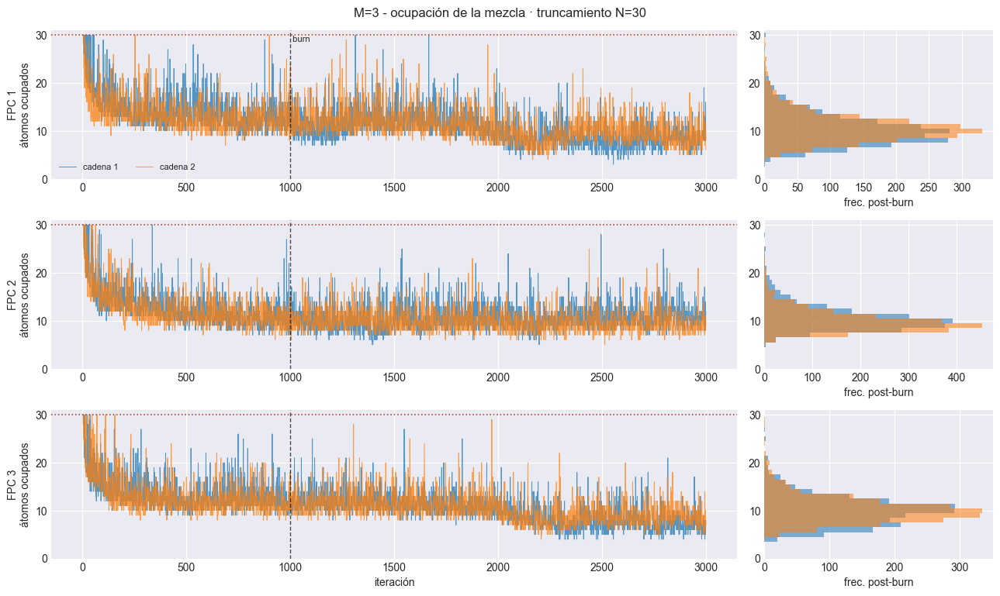

,M,FPC,cadena,media,max,p99,N_trunc,toca_truncamiento
0,3,1,1,10.17,30,20.0,30,True
1,3,1,2,10.65,29,20.0,30,False
2,3,2,1,10.50,28,19.0,30,False
3,3,2,2,9.84,25,17.0,30,False
4,3,3,1,9.87,27,18.0,30,False
5,3,3,2,10.14,29,19.0,30,False


! [M=3] alguna cadena alcanza N: el truncamiento está mordiendo. Subir mcmc_config['N'].


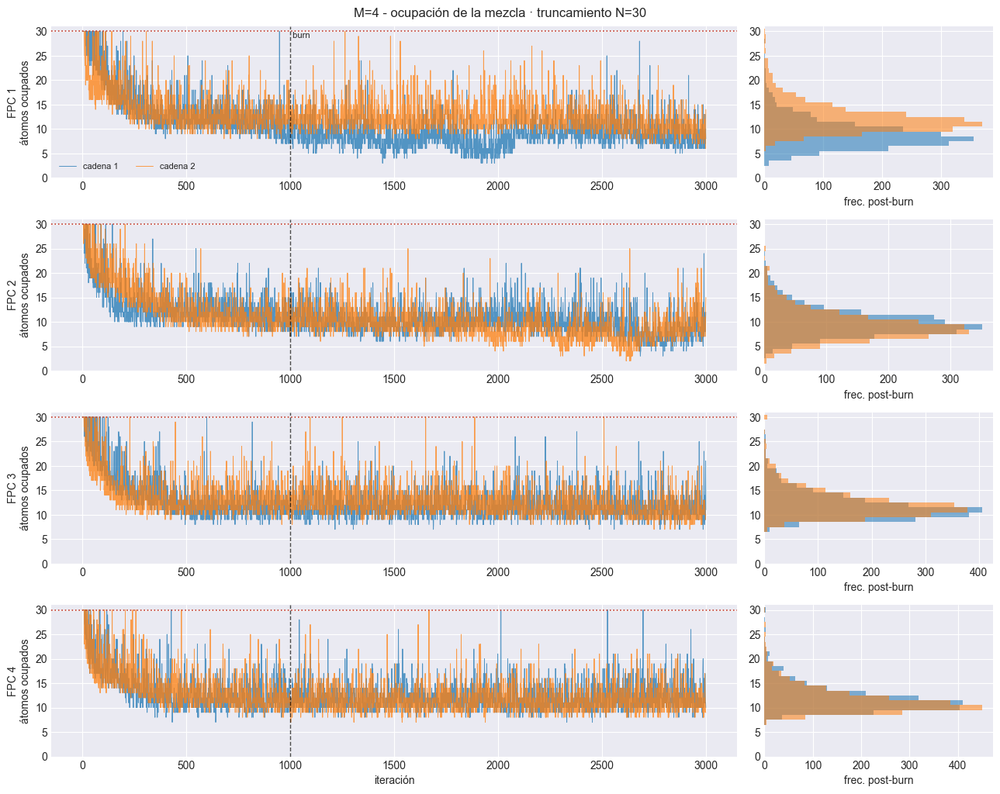

,M,FPC,cadena,media,max,p99,N_trunc,toca_truncamiento
0,4,1,1,8.85,28,18.0,30,False
1,4,1,2,12.21,30,22.0,30,True
2,4,2,1,9.92,24,19.0,30,False
3,4,2,2,9.12,25,19.0,30,False
4,4,3,1,11.70,27,20.0,30,False
5,4,3,2,12.25,30,21.0,30,True
6,4,4,1,11.87,30,21.0,30,True
7,4,4,2,11.53,30,21.0,30,True


! [M=4] alguna cadena alcanza N: el truncamiento está mordiendo. Subir mcmc_config['N'].


In [ ]:
for M in M_OK:
    e = EST[M]
    ci, n_comp = e["component_idx"], e["n_components"]
    N_ATOMOS, BURN = e["n_atomos"], e["burn"]

    fig, axes = plt.subplots(n_comp, 2, figsize=(13, 2.6 * n_comp),
                             squeeze=False, gridspec_kw={"width_ratios": [3, 1]})
    resumen_ocupacion = []

    for k in range(n_comp):
        ax_tr, ax_hi = axes[k]
        for c in sorted(e["models_chains"][k]):
            n1 = e["models_chains"][k][c].traces["N1out"]
            ax_tr.plot(np.arange(len(n1)), n1, lw=0.7, alpha=0.75,
                       label=f"cadena {c+1}")
            ax_hi.hist(n1[BURN:], bins=np.arange(0.5, N_ATOMOS + 1.5), alpha=0.55,
                       orientation="horizontal")
            post = n1[BURN:]
            resumen_ocupacion.append({
                "M": M, "FPC": ci[k] + 1, "cadena": c + 1,
                "media": post.mean(), "max": int(post.max()),
                "p99": float(np.quantile(post, 0.99)), "N_trunc": N_ATOMOS,
                "toca_truncamiento": bool(post.max() >= N_ATOMOS),
            })
        ax_tr.axvline(BURN, color="k", ls="--", lw=1, alpha=0.7)
        ax_tr.axhline(N_ATOMOS, color="#c0392b", ls=":", lw=1.2)
        ax_tr.set_ylabel(f"FPC {ci[k]+1}\nátomos ocupados")
        ax_tr.set_ylim(0, N_ATOMOS + 1)
        ax_hi.set_ylim(0, N_ATOMOS + 1)
        ax_hi.set_xlabel("frec. post-burn")
        if k == 0:
            ax_tr.legend(fontsize=8, ncol=3)
            ax_tr.text(BURN, N_ATOMOS, " burn", fontsize=8, va="top")
    axes[-1, 0].set_xlabel("iteración")
    fig.suptitle(f"M={M} - ocupación de la mezcla · truncamiento N={N_ATOMOS}",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(e["paths"]["out_report"] / "41_ocupacion_mezcla.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    ocup_df = pd.DataFrame(resumen_ocupacion)
    e["ocup_df"] = ocup_df
    display(ocup_df.style.format({"media": "{:.2f}", "p99": "{:.1f}"})
            .set_caption(f"M={M} - átomos ocupados post-calentamiento"))
    if ocup_df["toca_truncamiento"].any():
        print(f"! [M={M}] alguna cadena alcanza N: el truncamiento está "
              "mordiendo. Subir mcmc_config['N'].")
    else:
        print(f"OK [M={M}] ninguna cadena alcanza N={N_ATOMOS}: el truncamiento "
              "no restringe.")

### 4.1 Gating: $\psi$, $\alpha$, $\Gamma$

Diagnóstico de los parámetros de los pesos $\pi_h(x)$. Las variables son promedios ponderados por el peso medio de cada átomo, $\bar w_h=\frac1n\sum_i\pi_h(x_i)$, para que no dependan del etiquetado de la mezcla.

- **átomos ef. global / por punto:** $1/\sum_h\bar w_h^2$ y $\frac1n\sum_i 1/\sum_h\pi_h(x_i)^2$.
- **señal de gating:** global menos por punto. Vale ≈ 0 si los pesos son los mismos en todo $x$.
- **sd del argumento:** dispersión en $i$ de $\alpha_h-\sum_j\psi_{hj}|x_{ij}-\Gamma_{hj}|$, contra el `sd_gate_objetivo` del prior.
- **alpha, psi_j, Gamma_j:** promedios ponderados sobre los $N-1$ palos.

R-hat, ESS y Geweke salen de `diagnostico_variable`.

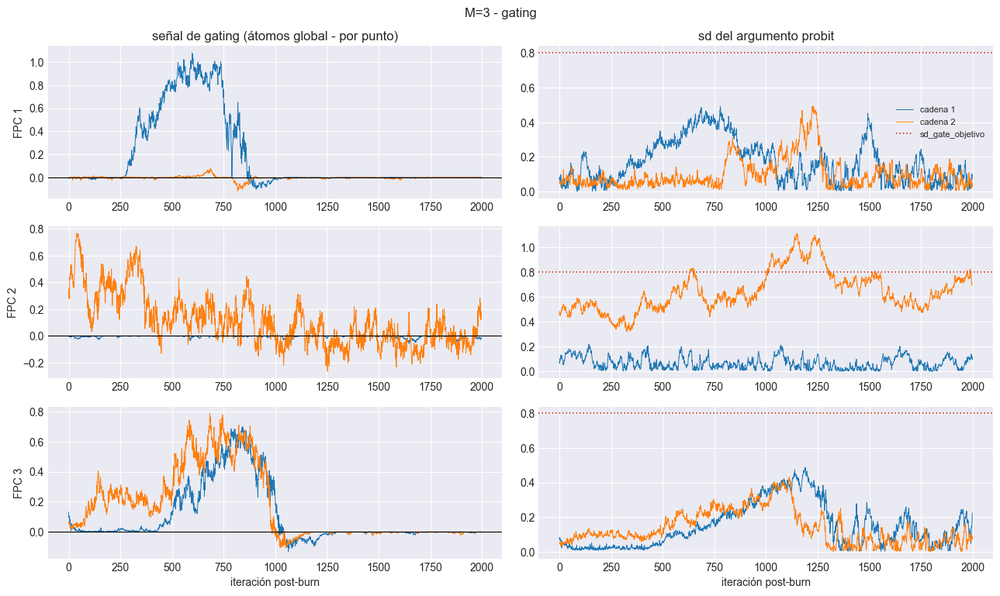

,M,FPC,variable,media_c1,media_c2,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,3,1,atomos_global,2.052,1.839,2,2000,4,5,7.931,1.012,False
1,3,1,atomos_punto,1.872,1.842,2,2000,4,5,7.944,1.000,False
2,3,1,senal_gating,0.180,-0.003,2,2000,6,16,1.864,1.147,False
3,3,1,sd_argumento,0.169,0.099,2,2000,7,9,1.635,1.103,False
4,3,1,alpha,1.145,0.836,2,2000,4,5,4.371,1.055,False
5,3,1,psi_0,0.237,0.123,2,2000,8,10,1.970,1.123,False
6,3,1,psi_1,0.000,0.000,2,2000,1223,1247,0.363,1.000,True
7,3,1,psi_2,0.000,0.022,2,2000,20,871,0.382,1.550,False
8,3,1,psi_3,0.000,0.016,2,2000,6,61,4.263,1.242,False
9,3,1,psi_4,0.005,0.000,2,2000,14,738,3.518,1.420,False


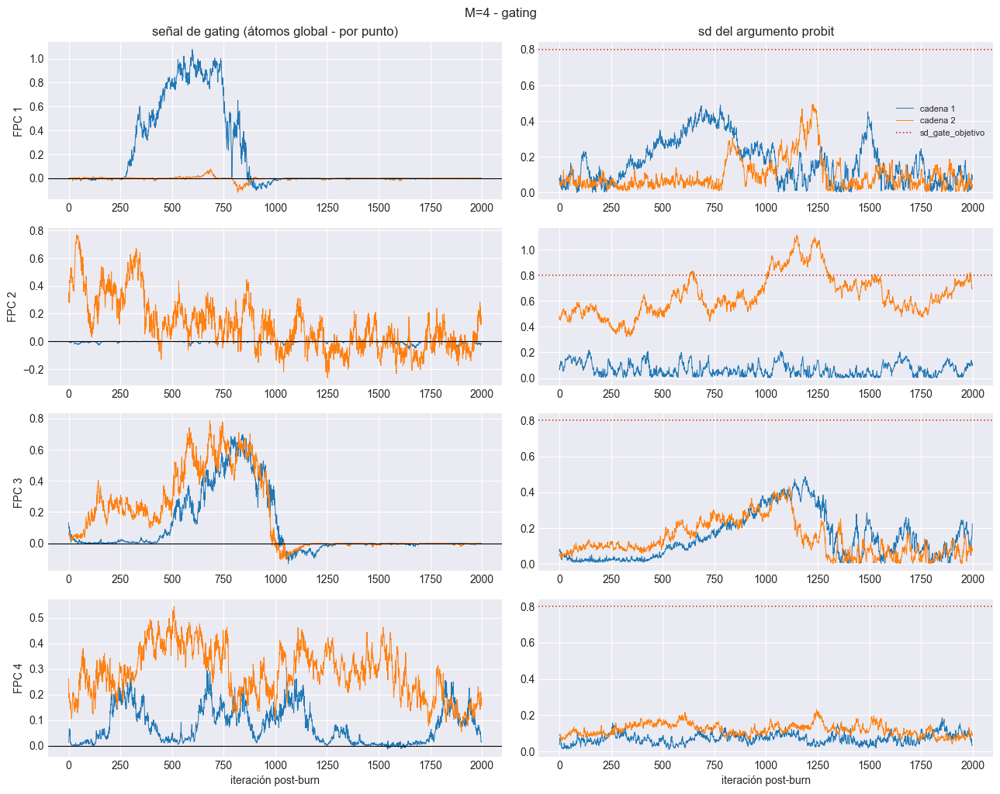

,M,FPC,variable,media_c1,media_c2,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,4,1,atomos_global,2.052,1.839,2,2000,4,5,7.931,1.012,False
1,4,1,atomos_punto,1.872,1.842,2,2000,4,5,7.944,1.000,False
2,4,1,senal_gating,0.180,-0.003,2,2000,6,16,1.864,1.147,False
3,4,1,sd_argumento,0.169,0.099,2,2000,7,9,1.635,1.103,False
4,4,1,alpha,1.145,0.836,2,2000,4,5,4.371,1.055,False
5,4,1,psi_0,0.237,0.123,2,2000,8,10,1.970,1.123,False
6,4,1,psi_1,0.000,0.000,2,2000,1223,1247,0.363,1.000,True
7,4,1,psi_2,0.000,0.022,2,2000,20,871,0.382,1.550,False
8,4,1,psi_3,0.000,0.016,2,2000,6,61,4.263,1.242,False
9,4,1,psi_4,0.005,0.000,2,2000,14,738,3.518,1.420,False


In [ ]:
from model_psbp_fd.models.pspb_fd_v3 import pesos_probit


def series_gating(mt, X):
    tr, b = mt.traces, mt.burn
    al, ps, gm = tr["alphahout"][b:], tr["psijhout"][b:], tr["Gammajhout"][b:]
    T, p = al.shape[0], X.shape[1]
    nombres = (["atomos_global", "atomos_punto", "senal_gating", "sd_argumento", "alpha"]
               + [f"psi_{j}" for j in range(p)] + [f"Gamma_{j}" for j in range(p)])
    S = {n: np.empty(T) for n in nombres}
    for t in range(T):
        w = pesos_probit(X, al[t], ps[t], gm[t])
        wbar = w.mean(0)
        s = wbar[:-1].sum()
        u = wbar[:-1] / s if s > 1e-12 else np.full(len(wbar) - 1, 1.0 / (len(wbar) - 1))
        eta = al[t][:, None] - np.sum(ps[t][:, None, :] * np.abs(X[None] - gm[t][:, None, :]), axis=2)
        S["atomos_global"][t] = 1.0 / np.sum(wbar ** 2)
        S["atomos_punto"][t] = np.mean(1.0 / np.sum(w ** 2, axis=1))
        S["sd_argumento"][t] = np.sum(u * eta.std(axis=1))
        S["alpha"][t] = np.sum(u * al[t])
        for j in range(p):
            S[f"psi_{j}"][t] = np.sum(u * ps[t][:, j])
            S[f"Gamma_{j}"][t] = np.sum(u * gm[t][:, j])
    S["senal_gating"] = S["atomos_global"] - S["atomos_punto"]
    return S


# Clave con M: cada punto del barrido tiene sus propias trazas y covariables.
_CACHE_GATING = {}

for M in M_OK:
    e = EST[M]
    ci, n_comp = e["component_idx"], e["n_components"]
    filas = []
    fig, axes = plt.subplots(n_comp, 2, figsize=(13, 2.6 * n_comp), squeeze=False)

    for k in range(n_comp):
        X = e["dfs_train"][k].iloc[:, 1:].to_numpy()
        cams = sorted(e["models_chains"][k])
        for c in cams:
            if (M, ci[k], c) not in _CACHE_GATING:
                _CACHE_GATING[(M, ci[k], c)] = series_gating(e["models_chains"][k][c], X)
        SER = {c: _CACHE_GATING[(M, ci[k], c)] for c in cams}
        obj = e["hp_json"].get("escalera", {}).get(str(k), {}).get("sd_gate_objetivo")

        for v in SER[cams[0]]:
            C = np.vstack([SER[c][v] for c in cams])
            fila = {"M": M, "FPC": ci[k] + 1, "variable": v}
            fila.update({f"media_c{c+1}": SER[c][v].mean() for c in cams})
            fila.update(diagnostico_variable(C))
            filas.append(fila)

        for c in cams:
            axes[k, 0].plot(SER[c]["senal_gating"], lw=0.7, label=f"cadena {c+1}")
            axes[k, 1].plot(SER[c]["sd_argumento"], lw=0.7, label=f"cadena {c+1}")
        axes[k, 0].axhline(0, color="k", lw=0.8)
        if obj is not None:
            axes[k, 1].axhline(obj, color="#c0392b", ls=":", lw=1.2, label="sd_gate_objetivo")
        axes[k, 0].set_ylabel(f"FPC {ci[k]+1}")
        if k == 0:
            axes[k, 0].set_title("señal de gating (átomos global - por punto)")
            axes[k, 1].set_title("sd del argumento probit")
            axes[k, 1].legend(fontsize=8)
    axes[-1, 0].set_xlabel("iteración post-burn")
    axes[-1, 1].set_xlabel("iteración post-burn")
    fig.suptitle(f"M={M} - gating", fontsize=12)
    fig.tight_layout()
    fig.savefig(e["paths"]["out_report"] / "49_gating.png", dpi=150, bbox_inches="tight")
    plt.show()

    gat = pd.DataFrame(filas)
    gat.to_csv(e["paths"]["out_report"] / "48_gating_diagnosticos.csv", index=False)
    e["gating_df"] = gat
    display(gat.style.format({c: "{:.3f}" for c in gat.columns
                              if c.startswith("media_") or c in ("rhat", "geweke_max")}
                             | {"ess_min": "{:.0f}", "ess_mean": "{:.0f}"})
            .set_caption(f"M={M} - gating post-calentamiento"))

## 5. Figuras de convergencia por parámetro

== M=3 ==============================================


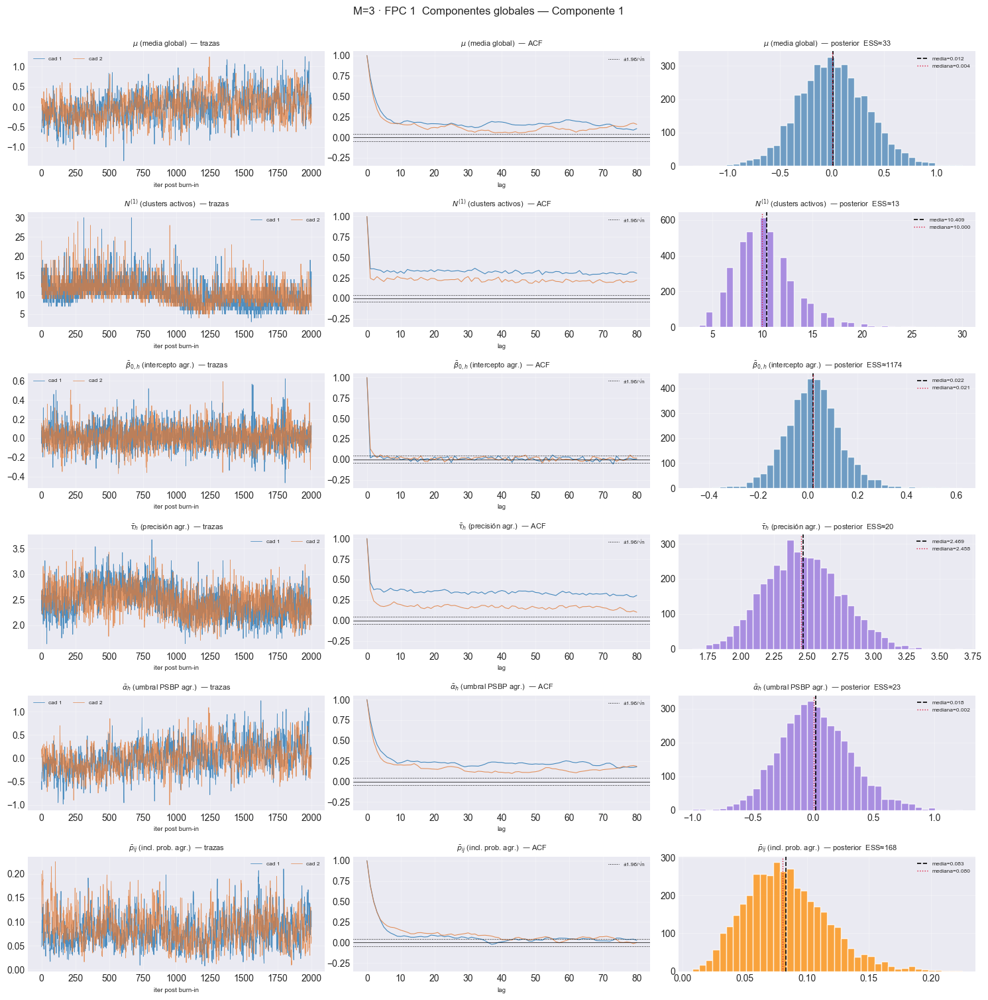

C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_global_components.py:276: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_global_components.py:278: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


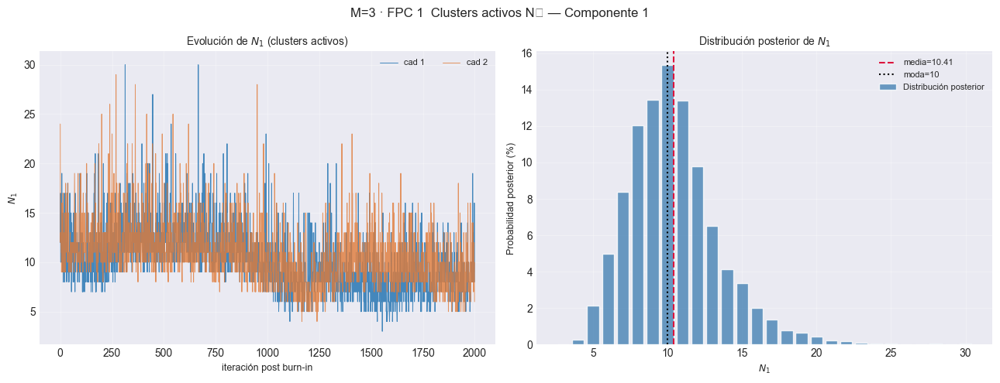

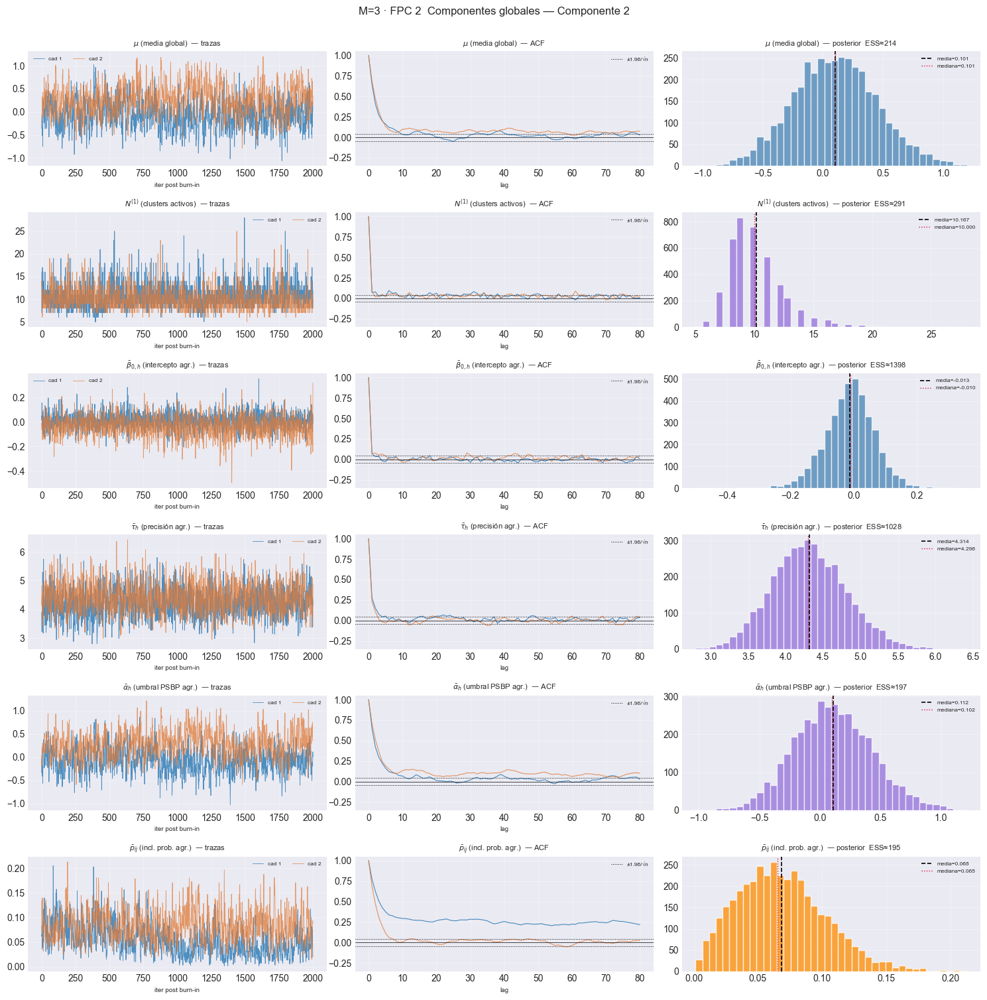

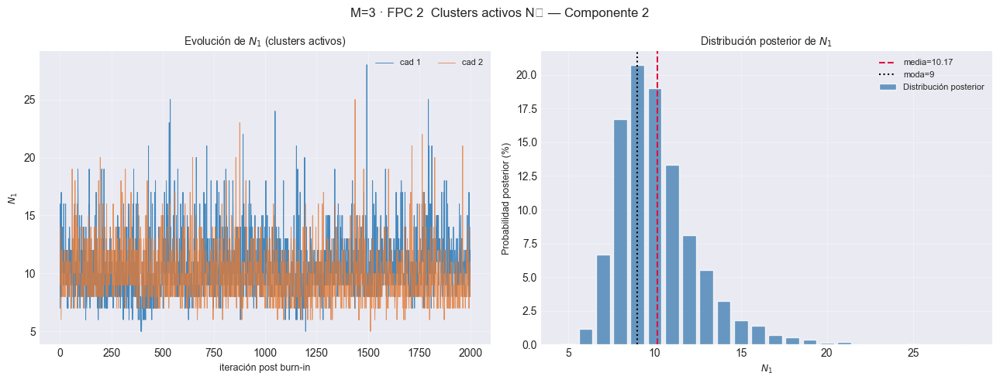

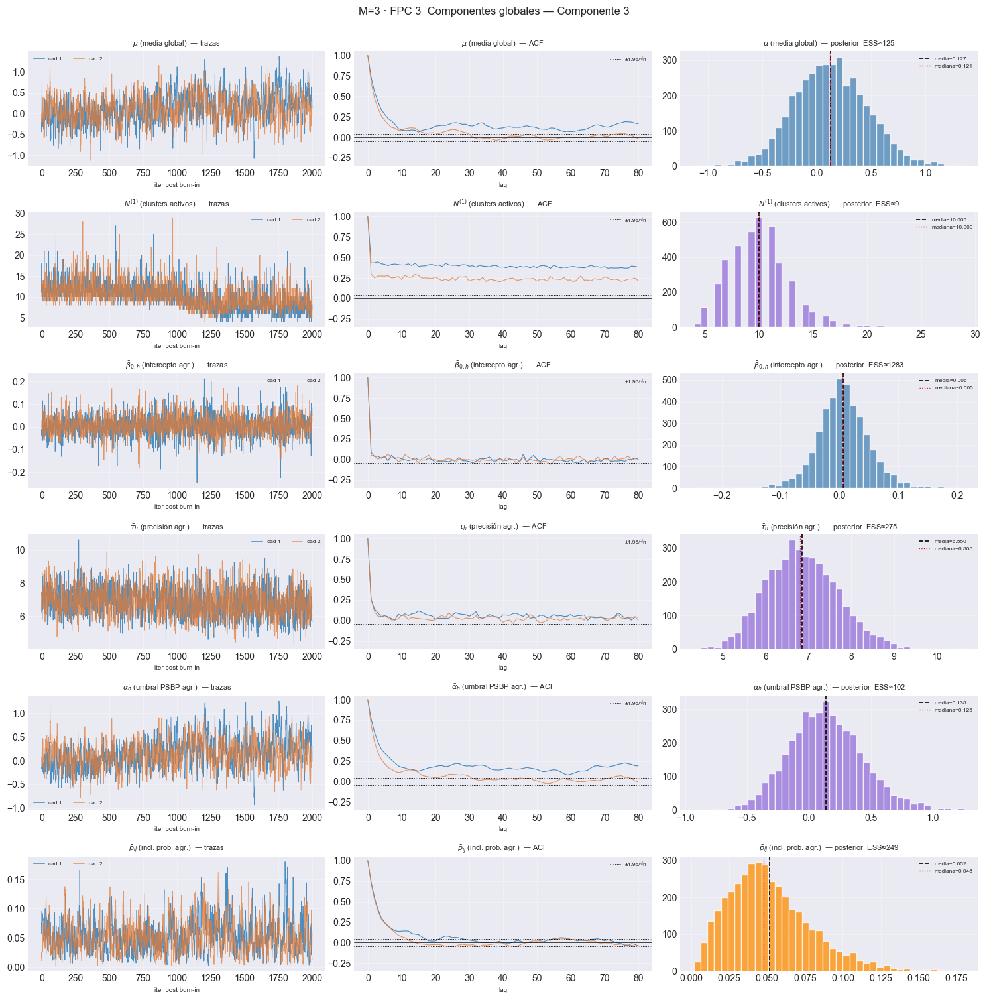

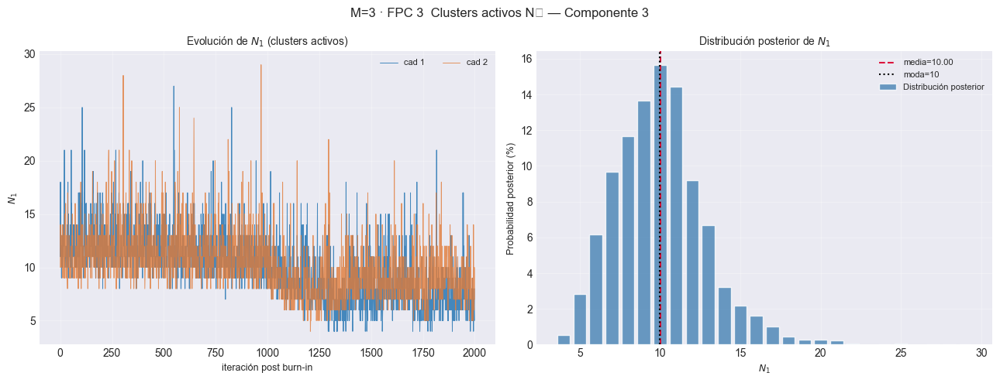

== M=4 ==============================================


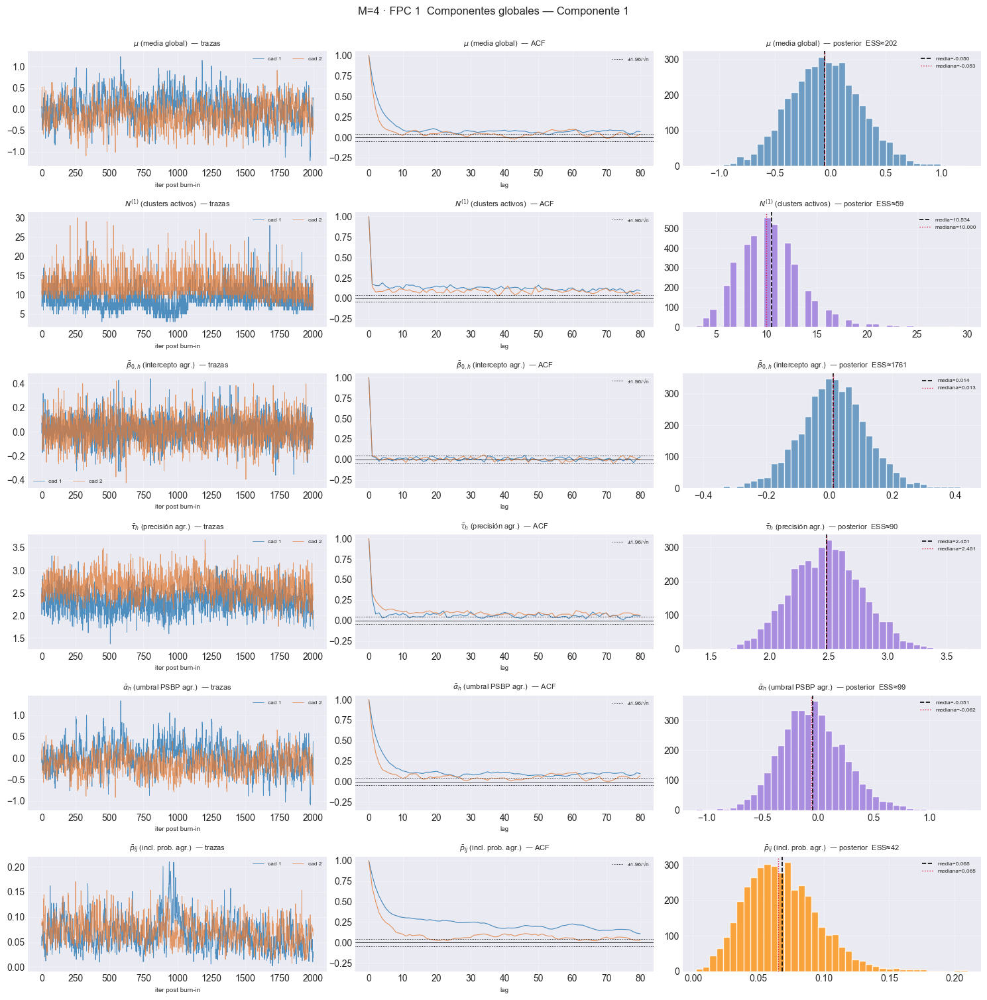

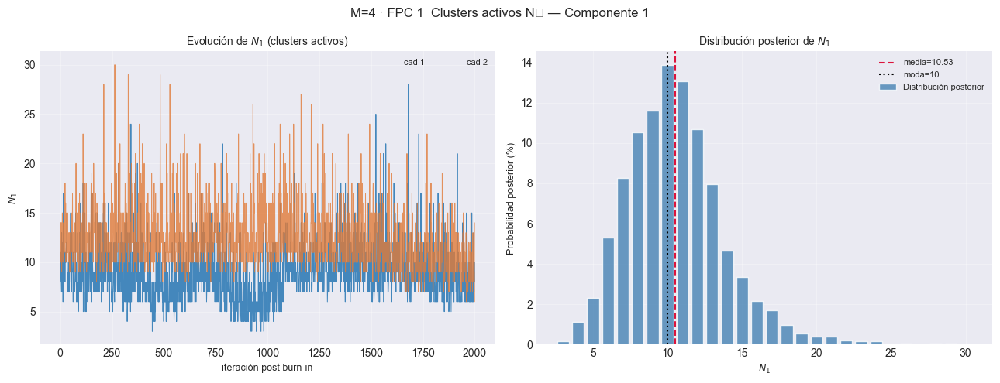

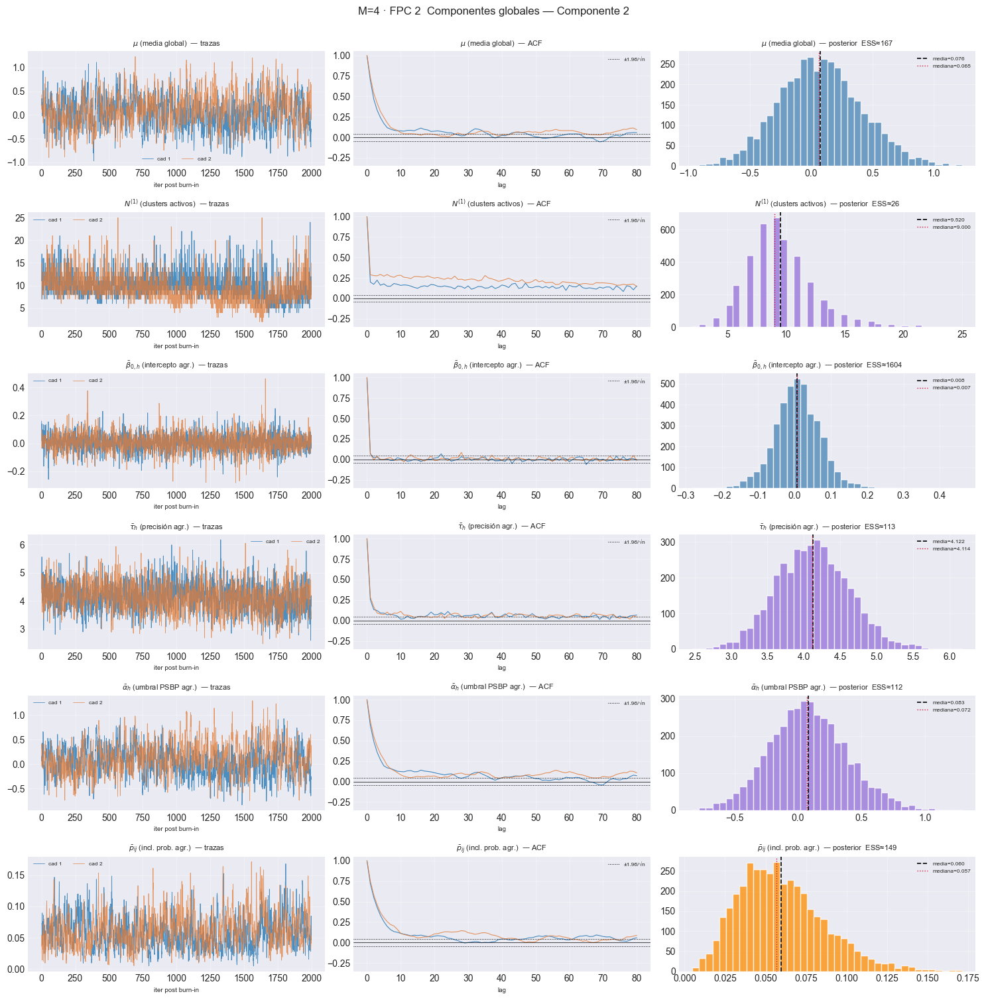

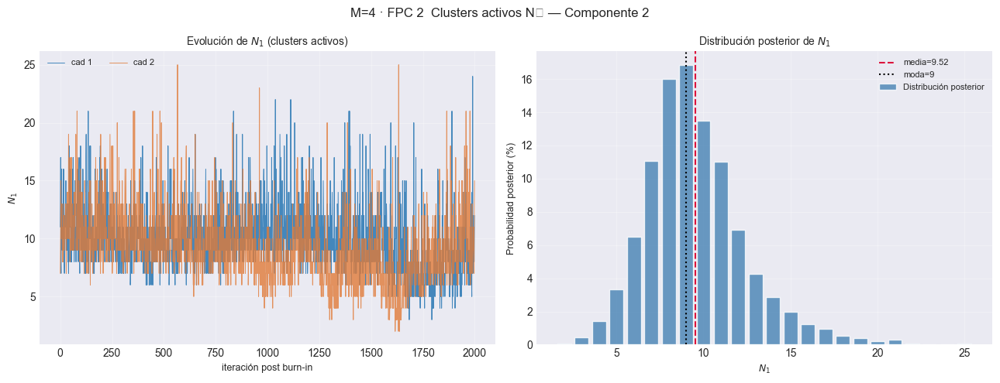

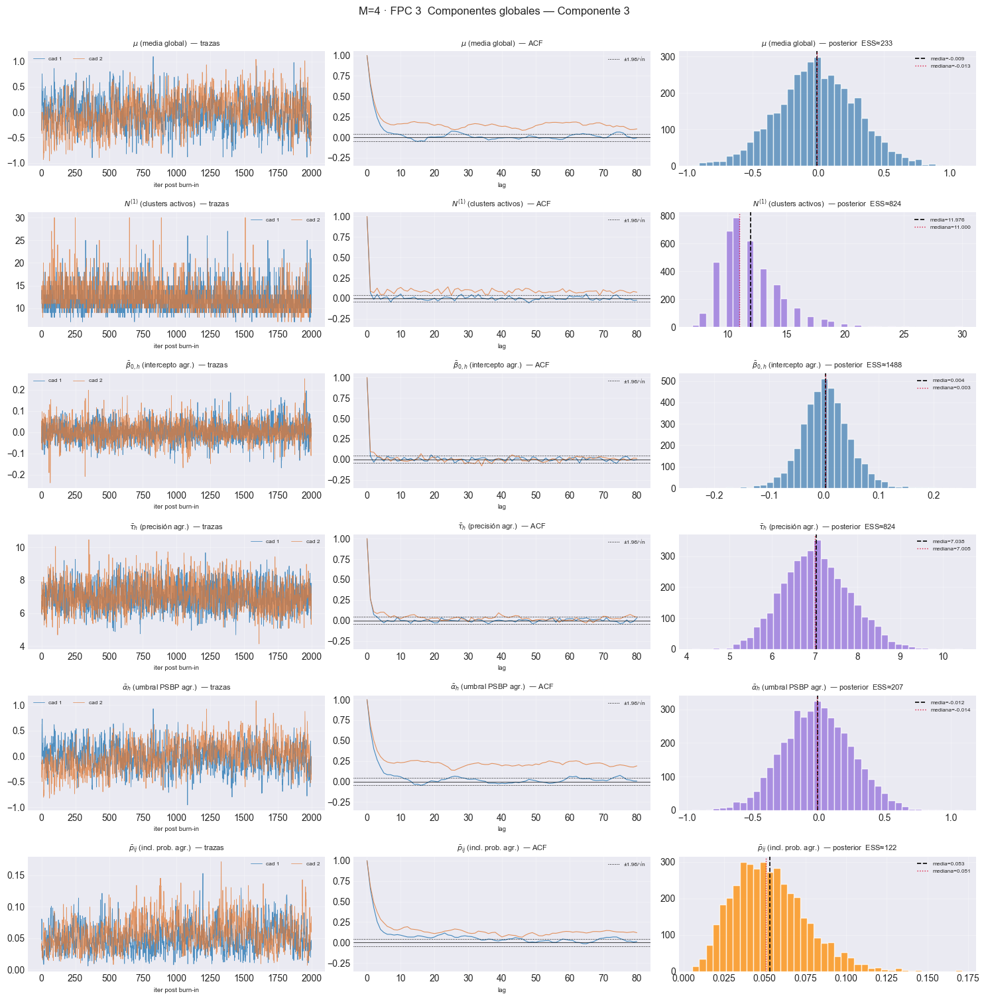

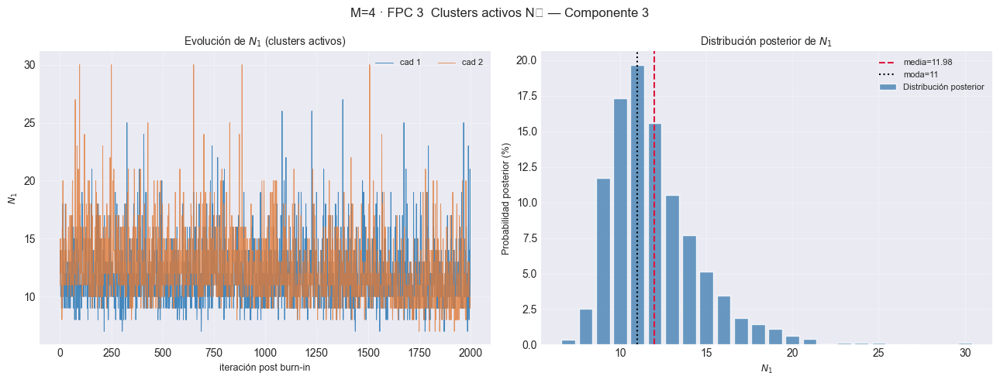

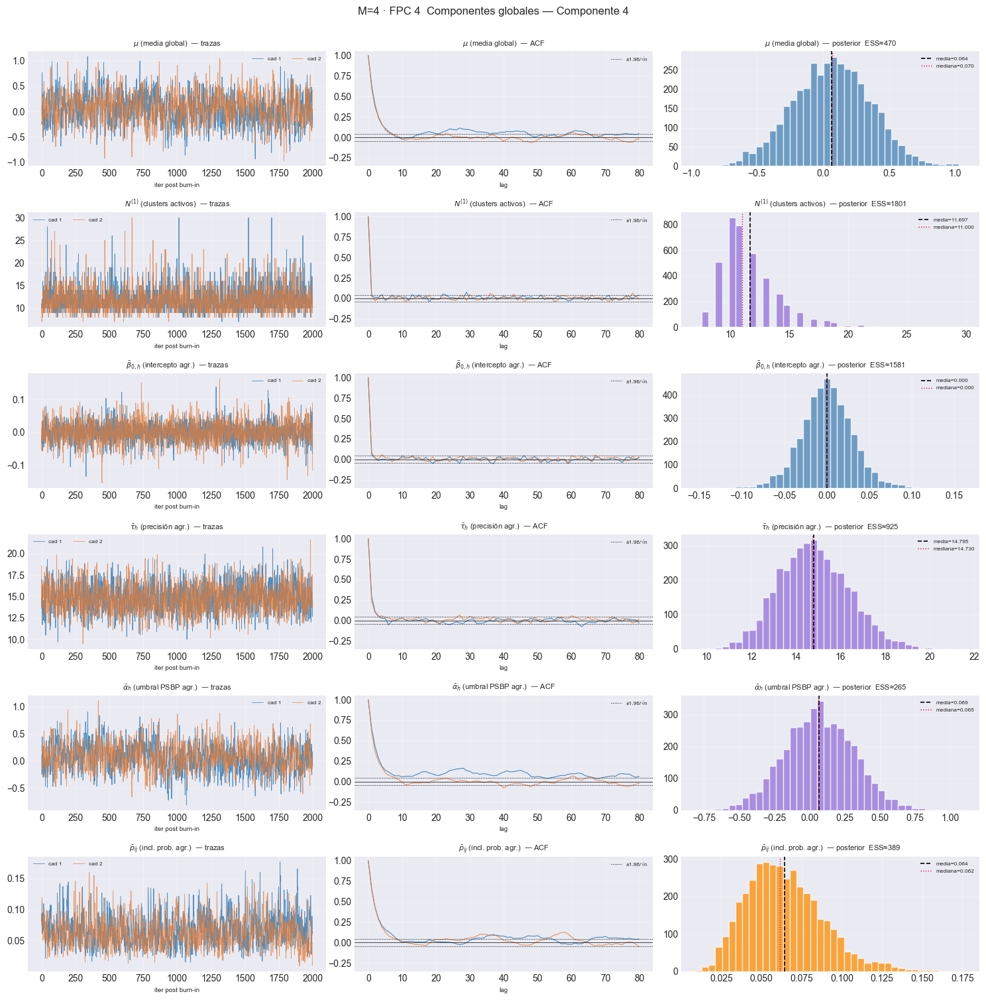

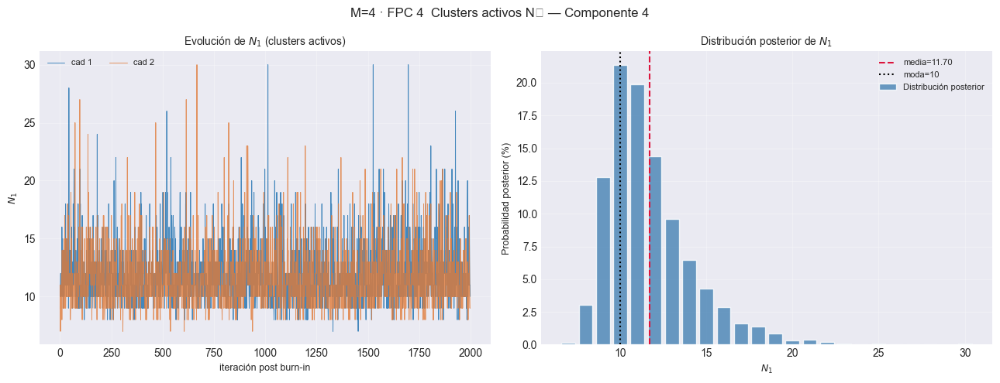

In [ ]:
for M in M_OK:
    e = EST[M]
    print(f"== M={M} " + "=" * 46)
    for k in e["models_chains"]:
        fpc = e["component_idx"][k] + 1
        plot_global_components(
            e["models_chains"], k, e["burn"], e["n_iter"],
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"42_global_k{fpc}.png"))
        plt.show()
        plot_active_clusters(
            e["models_chains"], k, e["burn"], e["n_iter"],
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"43_clusters_k{fpc}.png"))
        plt.show()

== M=3 ==============================================
[plot_convergence_bj[FPC 1]] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.008  ess_min=37  |G|=2.50  ✗
  2/6 (33.3%) t=0.1s eta=0.1s  fpc_2_lag1  rhat=1.000  ess_min=1755  |G|=1.34  ✓
  3/6 (50.0%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.006  ess_min=1552  |G|=0.11  ✓
  4/6 (66.7%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.072  ess_min=45  |G|=4.20  ✗
  5/6 (83.3%) t=0.2s eta=0.0s  fpc_2_lag2  rhat=1.000  ess_min=1251  |G|=1.26  ✓
  6/6 (100.0%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=2000  |G|=1.23  ✓


C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:348: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:348: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:350: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:350: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


[plot_convergence_bj[FPC 1]] listo: 6 pasos en 2.6s  2/6 sin converger


c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


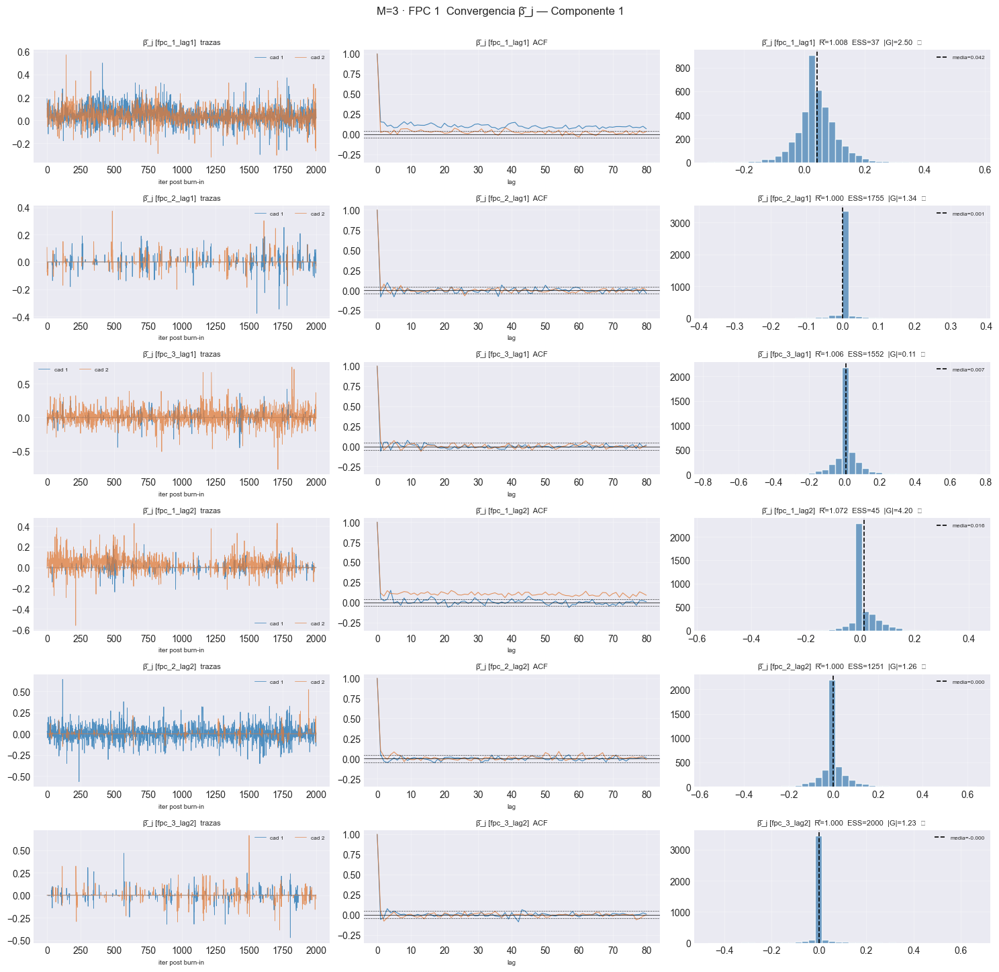

[plot_convergence_pj[FPC 1]] inicio (6 pasos)
  1/6 (16.7%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.054  ess_min=52  |G|=0.89  ✗
  2/6 (33.3%) t=0.2s eta=0.3s  fpc_2_lag1  rhat=1.005  ess_min=183  |G|=1.09  ✓
  3/6 (50.0%) t=0.2s eta=0.2s  fpc_3_lag1  rhat=1.505  ess_min=256  |G|=3.24  ✗
  4/6 (66.7%) t=0.3s eta=0.2s  fpc_1_lag2  rhat=1.300  ess_min=13  |G|=4.66  ✗
  5/6 (83.3%) t=0.4s eta=0.1s  fpc_2_lag2  rhat=1.578  ess_min=219  |G|=1.45  ✗
  6/6 (100.0%) t=0.4s eta=0.0s  fpc_3_lag2  rhat=1.002  ess_min=179  |G|=3.60  ✗


C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:447: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:447: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:449: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:449: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


[plot_convergence_pj[FPC 1]] listo: 6 pasos en 2.7s  5/6 sin converger


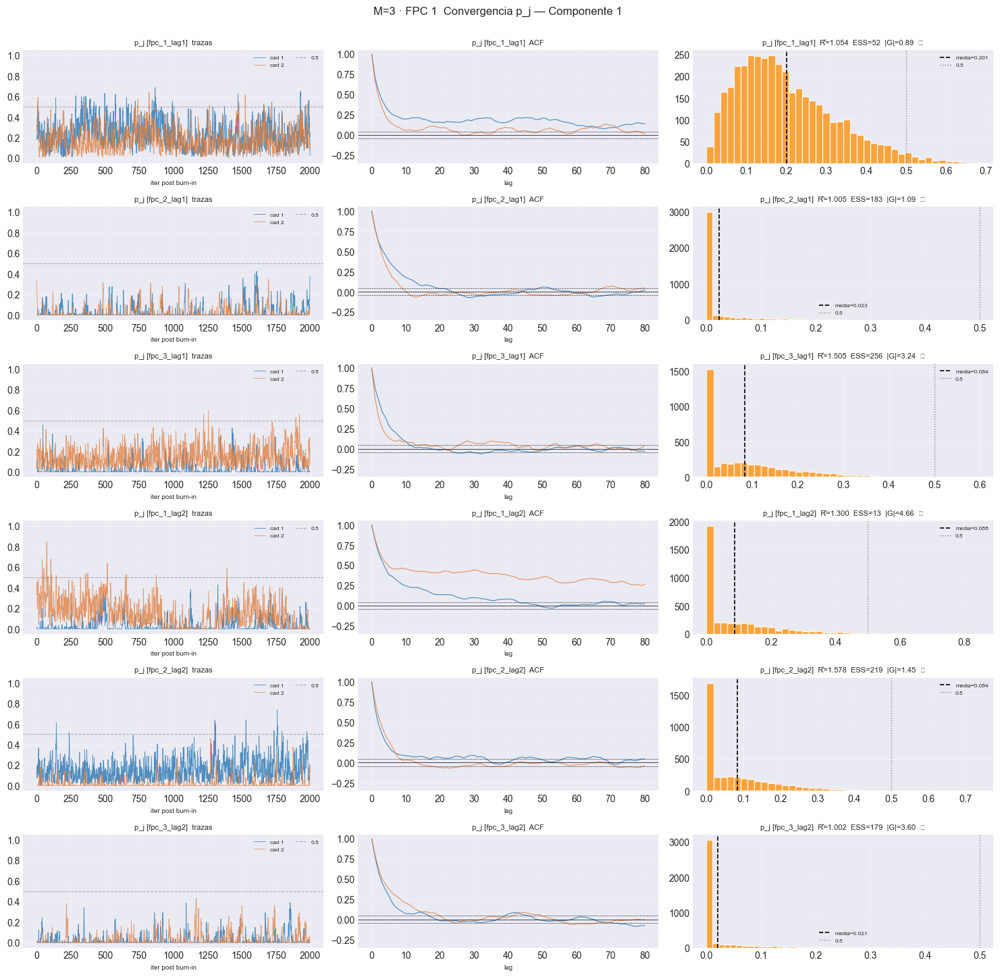

[plot_convergence_bj[FPC 2]] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.000  ess_min=1897  |G|=0.54  ✓
  2/6 (33.3%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.007  ess_min=1864  |G|=0.63  ✓
  3/6 (50.0%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.000  ess_min=2000  |G|=0.92  ✓
  4/6 (66.7%) t=0.2s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=1778  |G|=1.74  ✓
  5/6 (83.3%) t=0.2s eta=0.0s  fpc_2_lag2  rhat=1.000  ess_min=1944  |G|=1.28  ✓
  6/6 (100.0%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=1788  |G|=0.51  ✓
[plot_convergence_bj[FPC 2]] listo: 6 pasos en 3.2s  0/6 sin converger


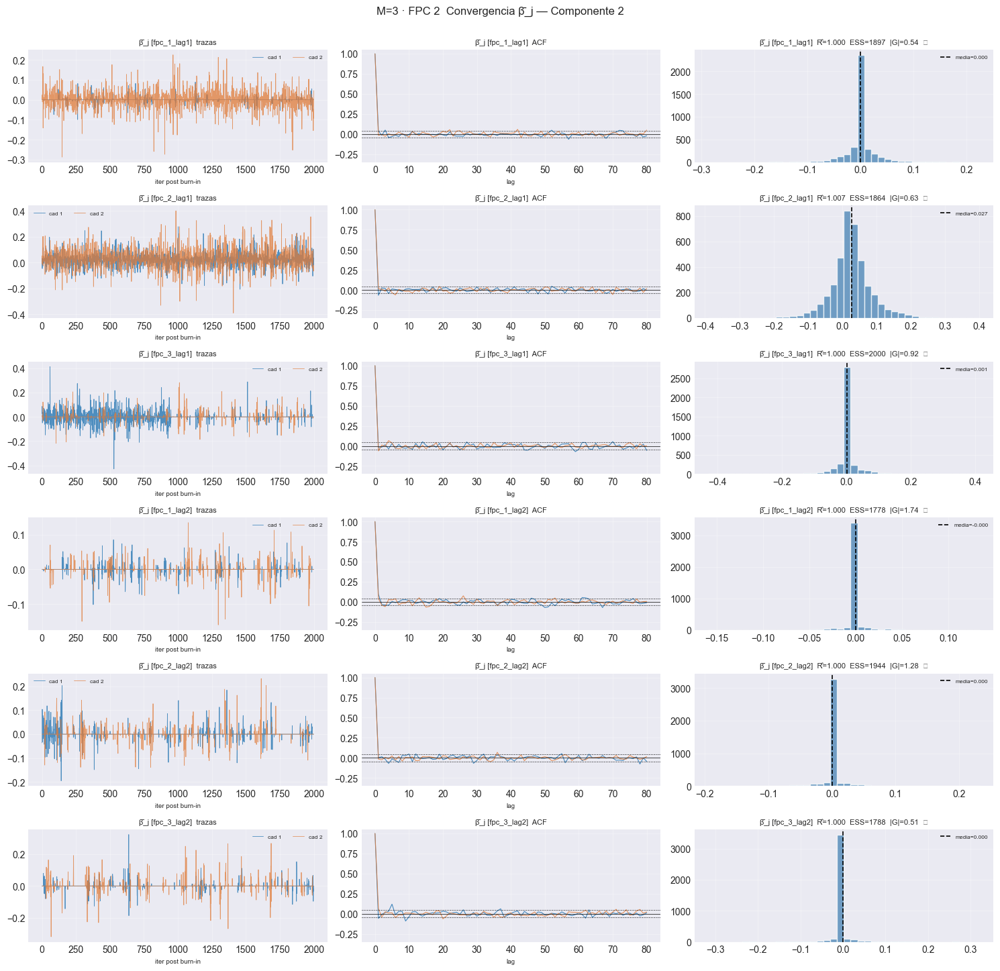

[plot_convergence_pj[FPC 2]] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.671  ess_min=364  |G|=1.06  ✗
  2/6 (33.3%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.153  ess_min=284  |G|=0.36  ✗
  3/6 (50.0%) t=0.2s eta=0.2s  fpc_3_lag1  rhat=1.128  ess_min=6  |G|=9.73  ✗
  4/6 (66.7%) t=0.3s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=245  |G|=2.79  ✗
  5/6 (83.3%) t=0.3s eta=0.1s  fpc_2_lag2  rhat=1.004  ess_min=45  |G|=3.04  ✗
  6/6 (100.0%) t=0.3s eta=0.0s  fpc_3_lag2  rhat=1.002  ess_min=252  |G|=0.94  ✓
[plot_convergence_pj[FPC 2]] listo: 6 pasos en 3.0s  5/6 sin converger


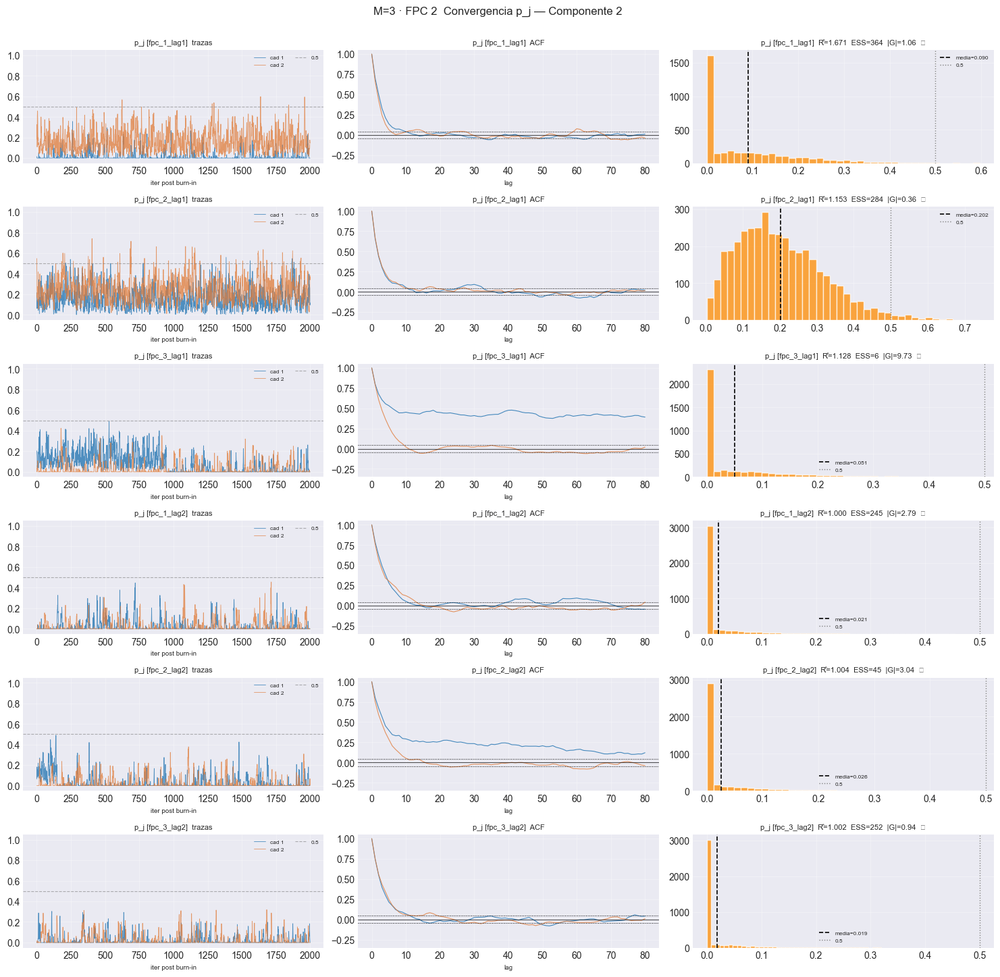

[plot_convergence_bj[FPC 3]] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.000  ess_min=762  |G|=0.47  ✓
  2/6 (33.3%) t=0.1s eta=0.1s  fpc_2_lag1  rhat=1.001  ess_min=1138  |G|=1.14  ✓
  3/6 (50.0%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.000  ess_min=495  |G|=2.79  ✗
  4/6 (66.7%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=1016  |G|=0.28  ✓
  5/6 (83.3%) t=0.2s eta=0.0s  fpc_2_lag2  rhat=1.000  ess_min=2000  |G|=0.79  ✓
  6/6 (100.0%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=1706  |G|=0.88  ✓
[plot_convergence_bj[FPC 3]] listo: 6 pasos en 2.4s  1/6 sin converger


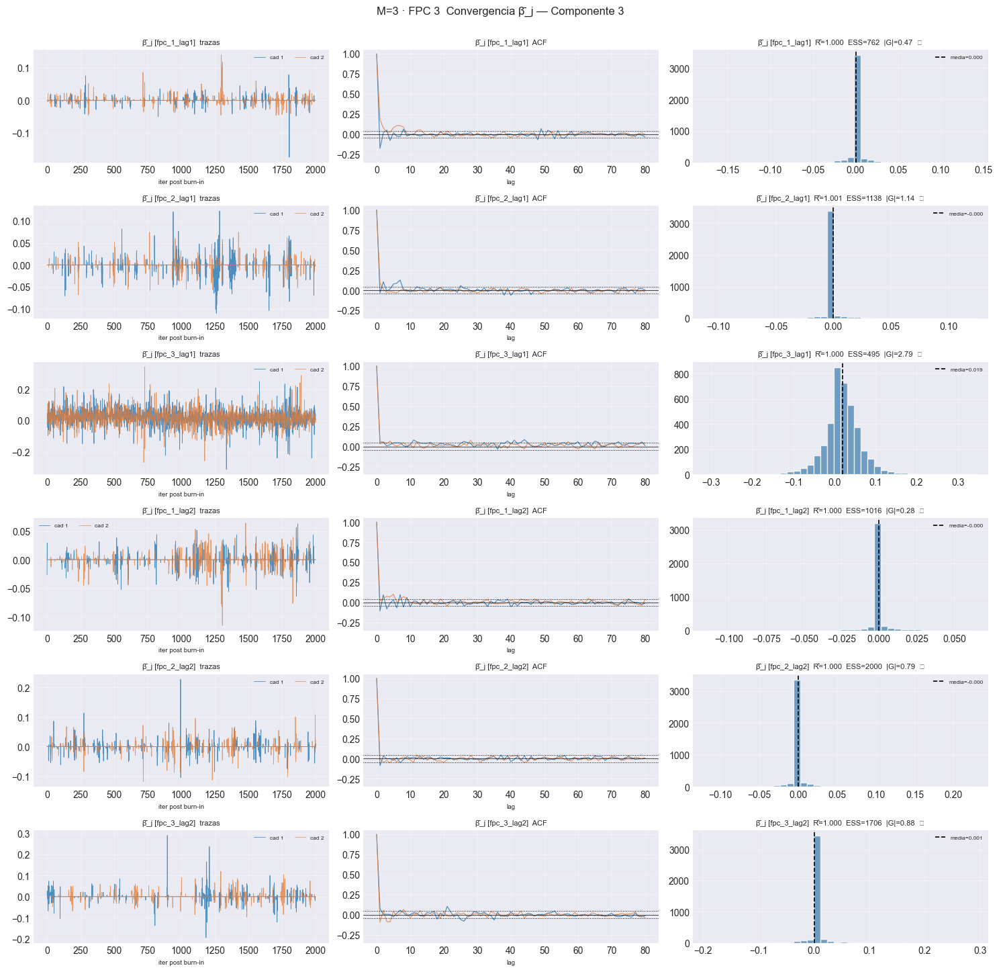

[plot_convergence_pj[FPC 3]] inicio (6 pasos)
  1/6 (16.7%) t=0.1s eta=0.3s  fpc_1_lag1  rhat=1.001  ess_min=175  |G|=1.55  ✓
  2/6 (33.3%) t=0.2s eta=0.3s  fpc_2_lag1  rhat=1.011  ess_min=120  |G|=2.08  ✗
  3/6 (50.0%) t=0.3s eta=0.3s  fpc_3_lag1  rhat=1.001  ess_min=66  |G|=3.14  ✗
  4/6 (66.7%) t=0.3s eta=0.2s  fpc_1_lag2  rhat=1.000  ess_min=58  |G|=4.48  ✗
  5/6 (83.3%) t=0.3s eta=0.1s  fpc_2_lag2  rhat=1.000  ess_min=241  |G|=0.77  ✓
  6/6 (100.0%) t=0.4s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=101  |G|=0.59  ✓
[plot_convergence_pj[FPC 3]] listo: 6 pasos en 3.1s  3/6 sin converger


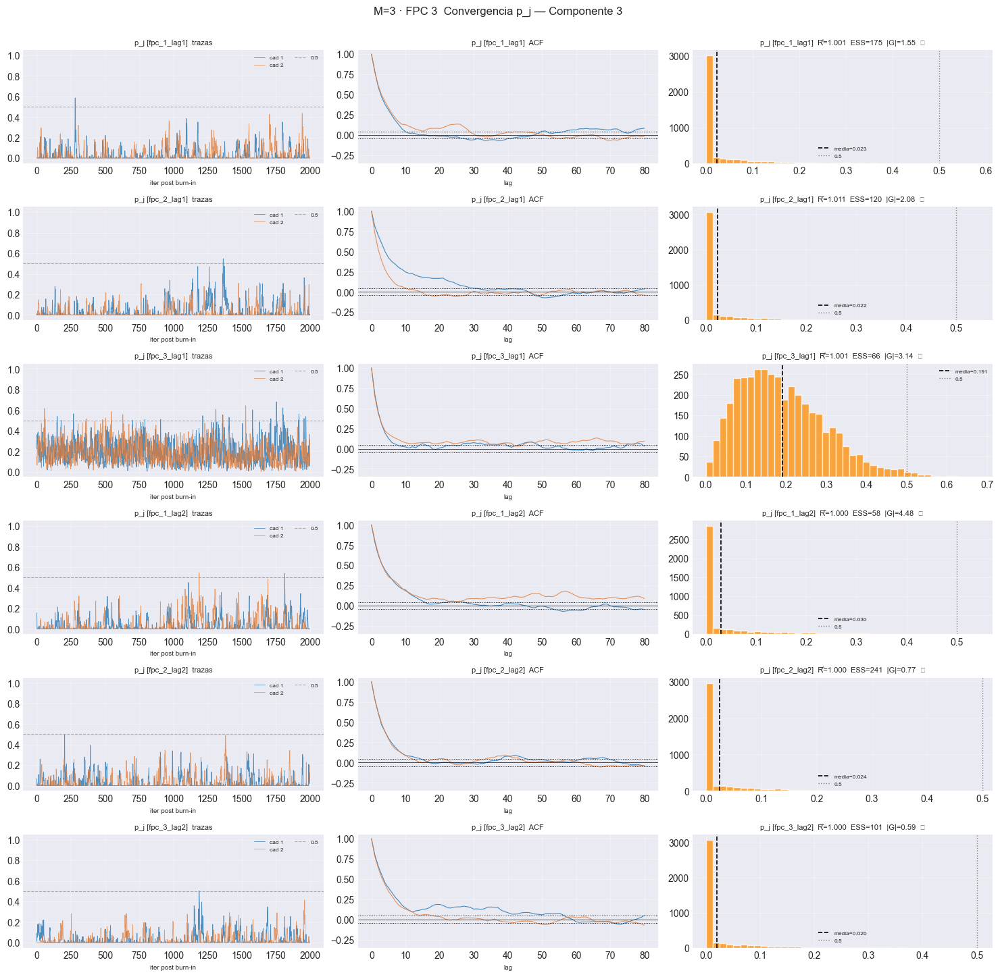

== M=4 ==============================================
[plot_convergence_bj[FPC 1]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.3s  fpc_1_lag1  rhat=1.089  ess_min=81  |G|=0.79  ✗
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.000  ess_min=1707  |G|=1.62  ✓
  3/8 (37.5%) t=0.1s eta=0.2s  fpc_3_lag1  rhat=1.001  ess_min=1407  |G|=2.99  ✗
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.000  ess_min=1341  |G|=1.74  ✓
  5/8 (62.5%) t=0.2s eta=0.1s  fpc_1_lag2  rhat=1.058  ess_min=356  |G|=2.54  ✗
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.000  ess_min=1590  |G|=0.40  ✓
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=1774  |G|=0.75  ✓
  8/8 (100.0%) t=0.3s eta=0.0s  fpc_4_lag2  rhat=1.000  ess_min=2000  |G|=1.19  ✓
[plot_convergence_bj[FPC 1]] listo: 8 pasos en 3.0s  3/8 sin converger


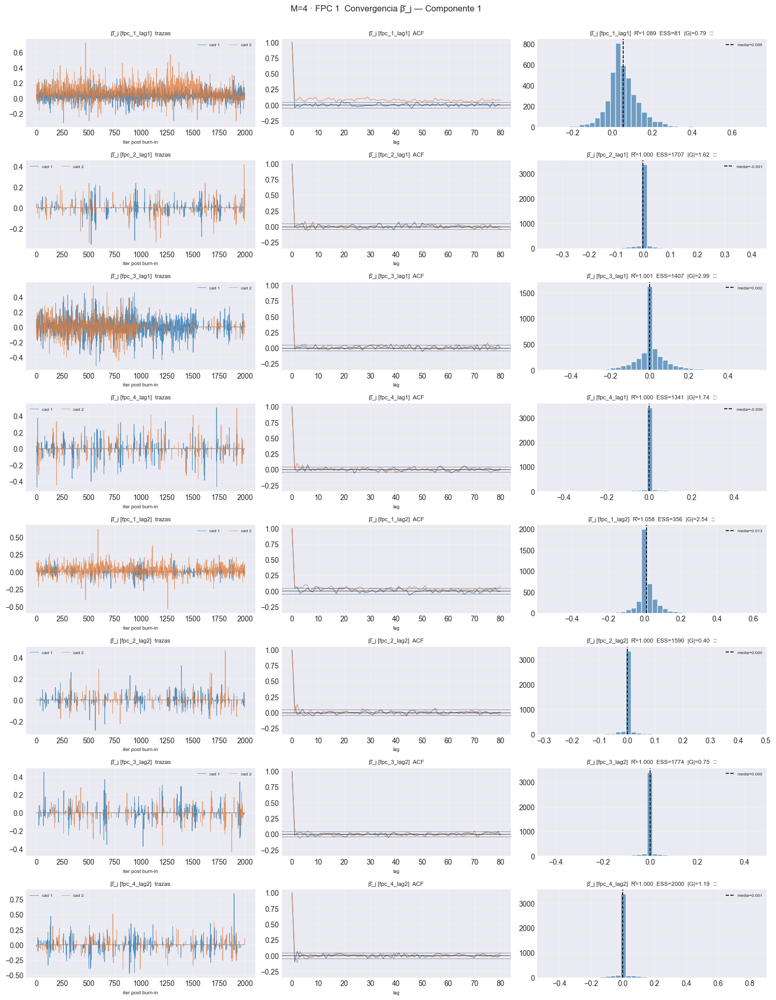

[plot_convergence_pj[FPC 1]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.102  ess_min=21  |G|=1.15  ✗
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.005  ess_min=161  |G|=2.92  ✗
  3/8 (37.5%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.108  ess_min=7  |G|=12.63  ✗
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.014  ess_min=256  |G|=1.42  ✓
  5/8 (62.5%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.200  ess_min=42  |G|=1.53  ✗
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.013  ess_min=253  |G|=4.36  ✗
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.006  ess_min=168  |G|=1.40  ✓
  8/8 (100.0%) t=0.2s eta=0.0s  fpc_4_lag2  rhat=1.018  ess_min=139  |G|=1.21  ✓
[plot_convergence_pj[FPC 1]] listo: 8 pasos en 2.8s  5/8 sin converger


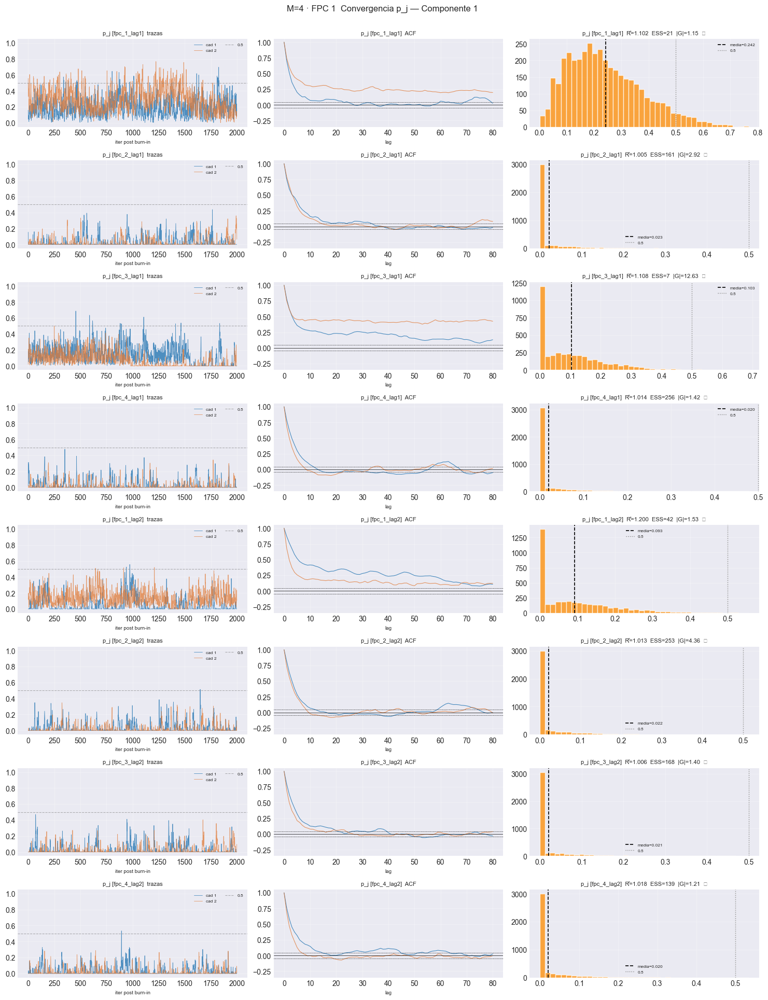

[plot_convergence_bj[FPC 2]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.000  ess_min=2000  |G|=1.45  ✓
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.000  ess_min=1842  |G|=1.58  ✓
  3/8 (37.5%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.000  ess_min=1680  |G|=1.18  ✓
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.000  ess_min=1718  |G|=2.11  ✗
  5/8 (62.5%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=2000  |G|=2.06  ✗
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.000  ess_min=1242  |G|=1.10  ✓
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=1333  |G|=0.74  ✓
  8/8 (100.0%) t=0.2s eta=0.0s  fpc_4_lag2  rhat=1.000  ess_min=1924  |G|=2.13  ✗
[plot_convergence_bj[FPC 2]] listo: 8 pasos en 3.0s  3/8 sin converger


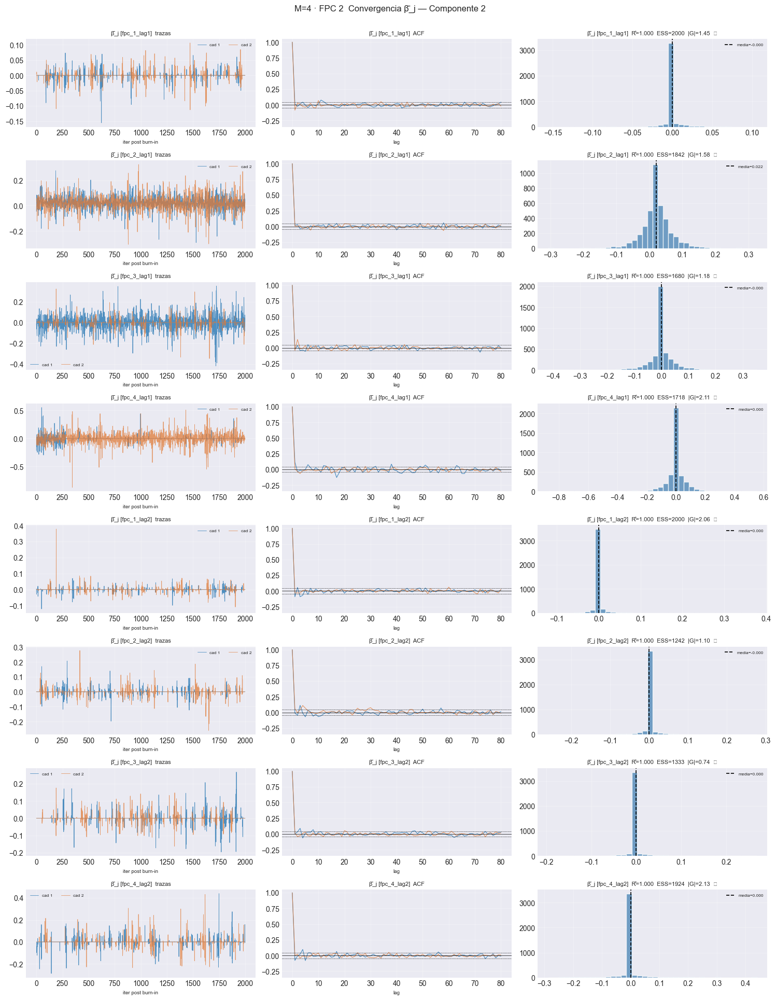

[plot_convergence_pj[FPC 2]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.001  ess_min=188  |G|=0.69  ✓
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.015  ess_min=374  |G|=2.13  ✗
  3/8 (37.5%) t=0.1s eta=0.2s  fpc_3_lag1  rhat=1.482  ess_min=252  |G|=1.01  ✗
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.419  ess_min=18  |G|=9.97  ✗
  5/8 (62.5%) t=0.2s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=153  |G|=1.50  ✓
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.002  ess_min=119  |G|=0.85  ✓
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.000  ess_min=188  |G|=4.04  ✗
  8/8 (100.0%) t=0.3s eta=0.0s  fpc_4_lag2  rhat=1.000  ess_min=187  |G|=0.94  ✓
[plot_convergence_pj[FPC 2]] listo: 8 pasos en 3.5s  4/8 sin converger


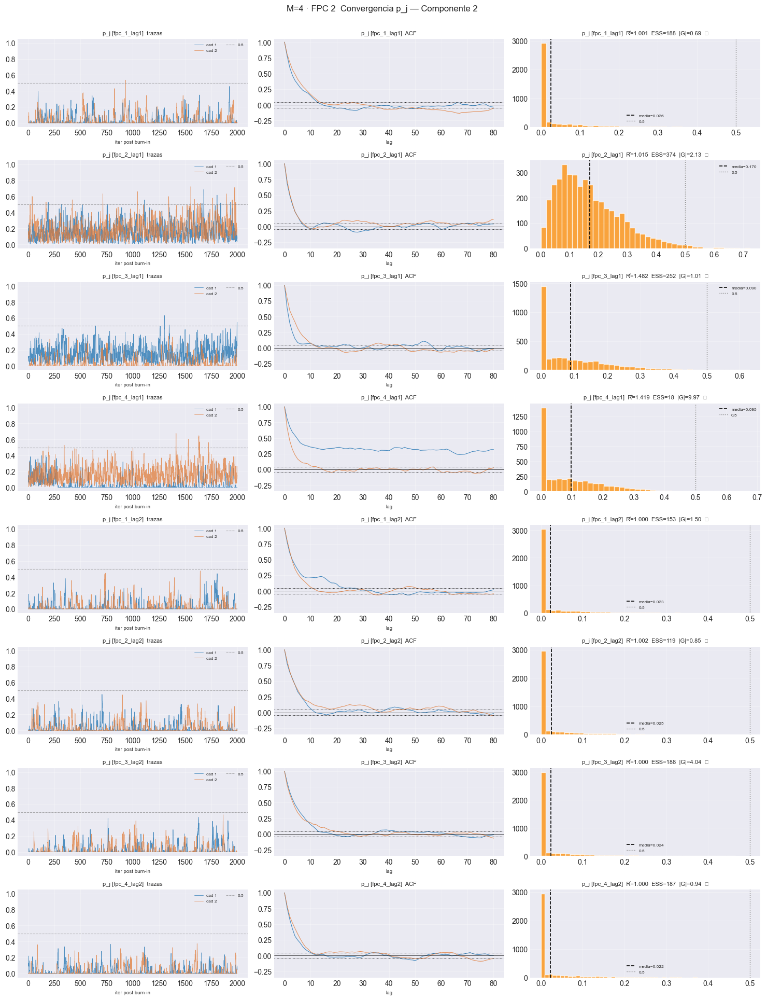

[plot_convergence_bj[FPC 3]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.3s  fpc_1_lag1  rhat=1.000  ess_min=2000  |G|=1.32  ✓
  2/8 (25.0%) t=0.1s eta=0.3s  fpc_2_lag1  rhat=1.013  ess_min=47  |G|=4.62  ✗
  3/8 (37.5%) t=0.1s eta=0.2s  fpc_3_lag1  rhat=1.000  ess_min=1854  |G|=1.61  ✓
  4/8 (50.0%) t=0.2s eta=0.2s  fpc_4_lag1  rhat=1.000  ess_min=1958  |G|=1.16  ✓
  5/8 (62.5%) t=0.6s eta=0.4s  fpc_1_lag2  rhat=1.000  ess_min=1494  |G|=1.80  ✓
  6/8 (75.0%) t=0.7s eta=0.2s  fpc_2_lag2  rhat=1.000  ess_min=2000  |G|=0.44  ✓
  7/8 (87.5%) t=0.7s eta=0.1s  fpc_3_lag2  rhat=1.000  ess_min=2000  |G|=0.37  ✓
  8/8 (100.0%) t=0.8s eta=0.0s  fpc_4_lag2  rhat=1.014  ess_min=841  |G|=1.01  ✓
[plot_convergence_bj[FPC 3]] listo: 8 pasos en 3.2s  1/8 sin converger


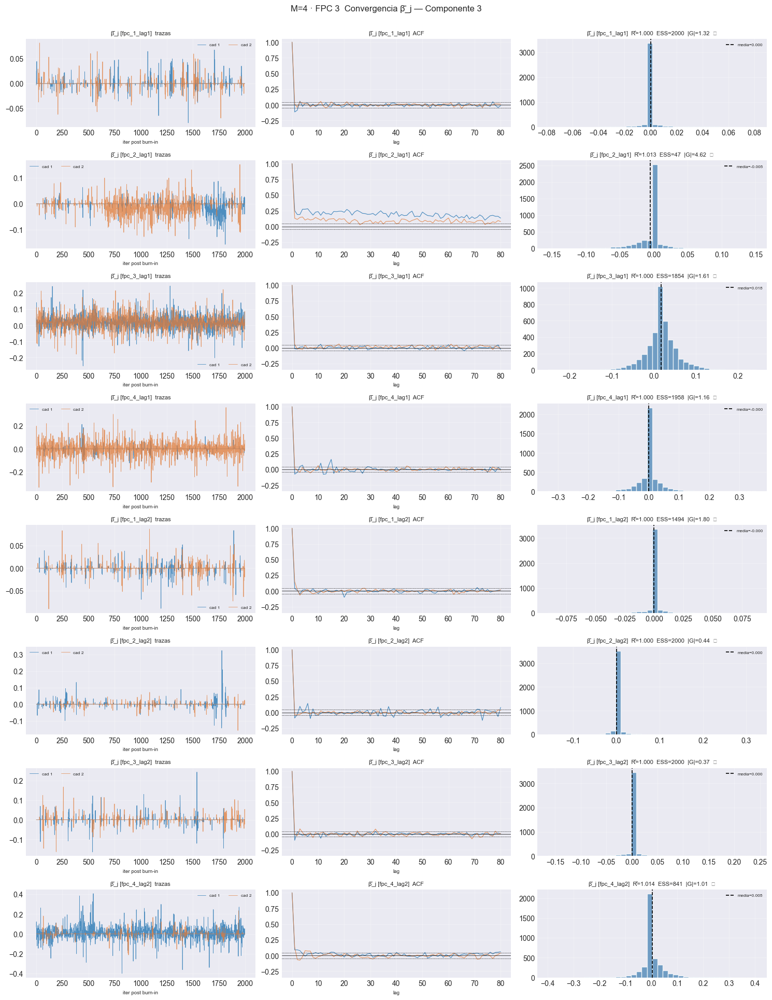

[plot_convergence_pj[FPC 3]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.000  ess_min=260  |G|=1.36  ✓
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.088  ess_min=16  |G|=2.24  ✗
  3/8 (37.5%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.011  ess_min=286  |G|=1.70  ✓
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.589  ess_min=262  |G|=0.99  ✗
  5/8 (62.5%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.006  ess_min=163  |G|=3.59  ✗
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.005  ess_min=165  |G|=2.85  ✗
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.001  ess_min=295  |G|=0.42  ✓
  8/8 (100.0%) t=0.2s eta=0.0s  fpc_4_lag2  rhat=1.530  ess_min=251  |G|=0.70  ✗
[plot_convergence_pj[FPC 3]] listo: 8 pasos en 2.7s  5/8 sin converger


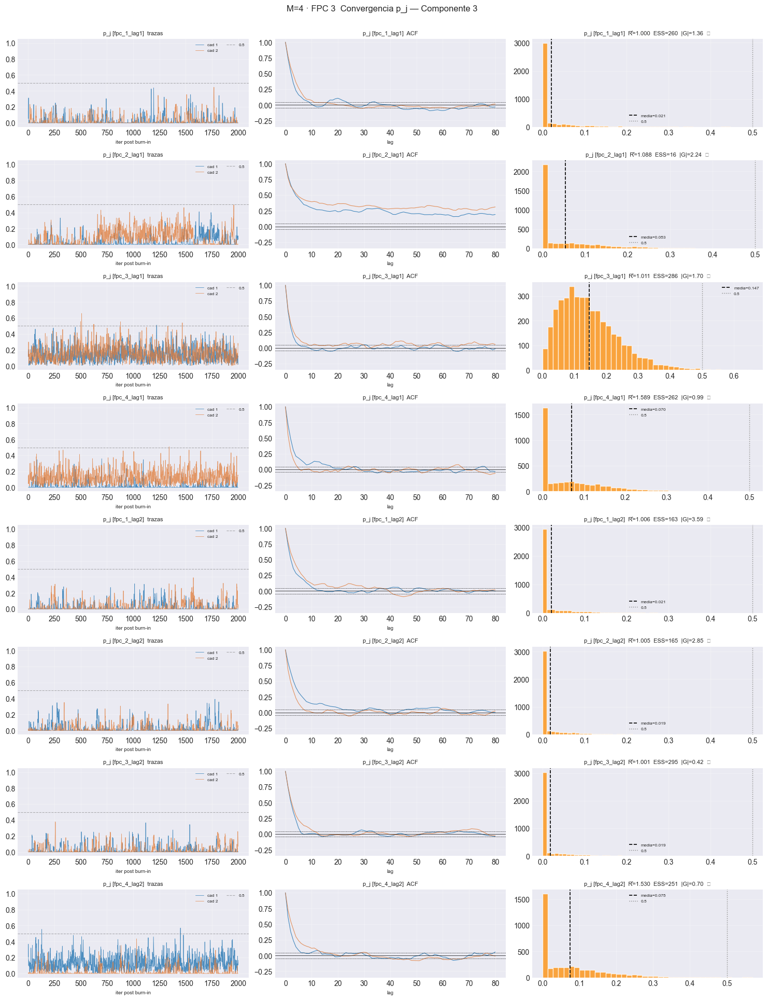

[plot_convergence_bj[FPC 4]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.001  ess_min=1569  |G|=0.73  ✓
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.001  ess_min=1651  |G|=0.99  ✓
  3/8 (37.5%) t=0.1s eta=0.1s  fpc_3_lag1  rhat=1.000  ess_min=1954  |G|=0.42  ✓
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.002  ess_min=1681  |G|=2.02  ✗
  5/8 (62.5%) t=0.1s eta=0.1s  fpc_1_lag2  rhat=1.000  ess_min=1725  |G|=0.84  ✓
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.000  ess_min=1346  |G|=0.72  ✓
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.020  ess_min=992  |G|=3.63  ✗
  8/8 (100.0%) t=0.2s eta=0.0s  fpc_4_lag2  rhat=1.016  ess_min=1711  |G|=0.76  ✓
[plot_convergence_bj[FPC 4]] listo: 8 pasos en 3.0s  2/8 sin converger


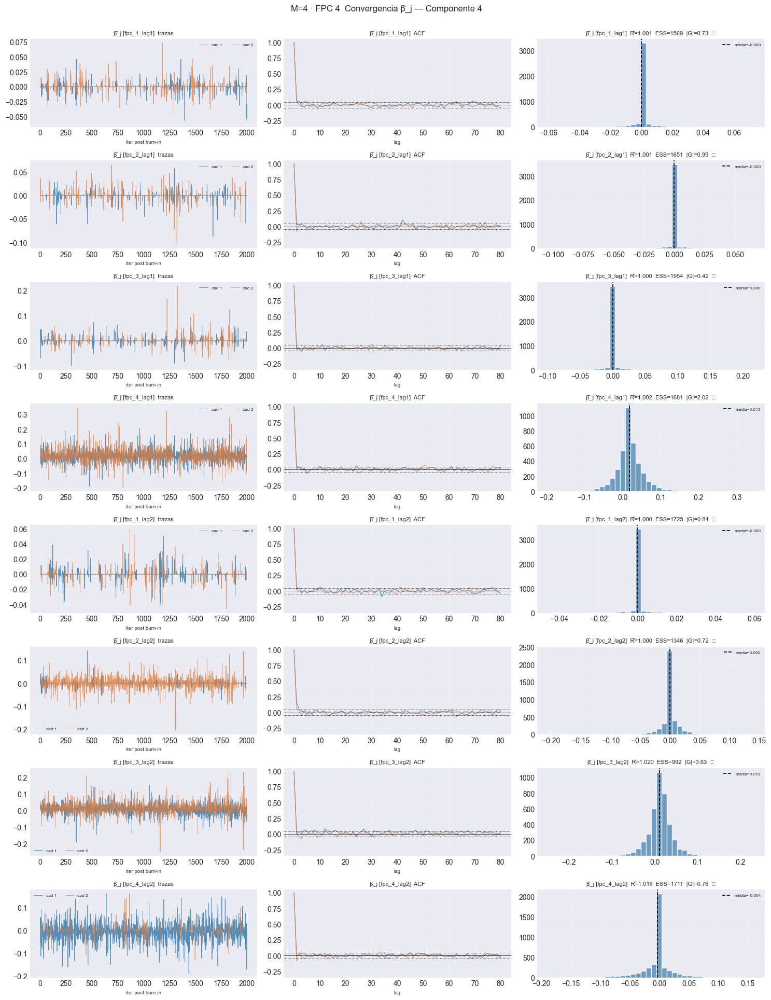

[plot_convergence_pj[FPC 4]] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.2s  fpc_1_lag1  rhat=1.000  ess_min=275  |G|=0.65  ✓
  2/8 (25.0%) t=0.1s eta=0.2s  fpc_2_lag1  rhat=1.000  ess_min=310  |G|=1.28  ✓
  3/8 (37.5%) t=0.1s eta=0.2s  fpc_3_lag1  rhat=1.000  ess_min=299  |G|=0.25  ✓
  4/8 (50.0%) t=0.1s eta=0.1s  fpc_4_lag1  rhat=1.000  ess_min=344  |G|=0.17  ✓
  5/8 (62.5%) t=0.2s eta=0.1s  fpc_1_lag2  rhat=1.004  ess_min=166  |G|=0.87  ✓
  6/8 (75.0%) t=0.2s eta=0.1s  fpc_2_lag2  rhat=1.437  ess_min=186  |G|=0.69  ✗
  7/8 (87.5%) t=0.2s eta=0.0s  fpc_3_lag2  rhat=1.008  ess_min=40  |G|=2.70  ✗
  8/8 (100.0%) t=0.2s eta=0.0s  fpc_4_lag2  rhat=1.555  ess_min=229  |G|=0.59  ✗
[plot_convergence_pj[FPC 4]] listo: 8 pasos en 2.7s  3/8 sin converger


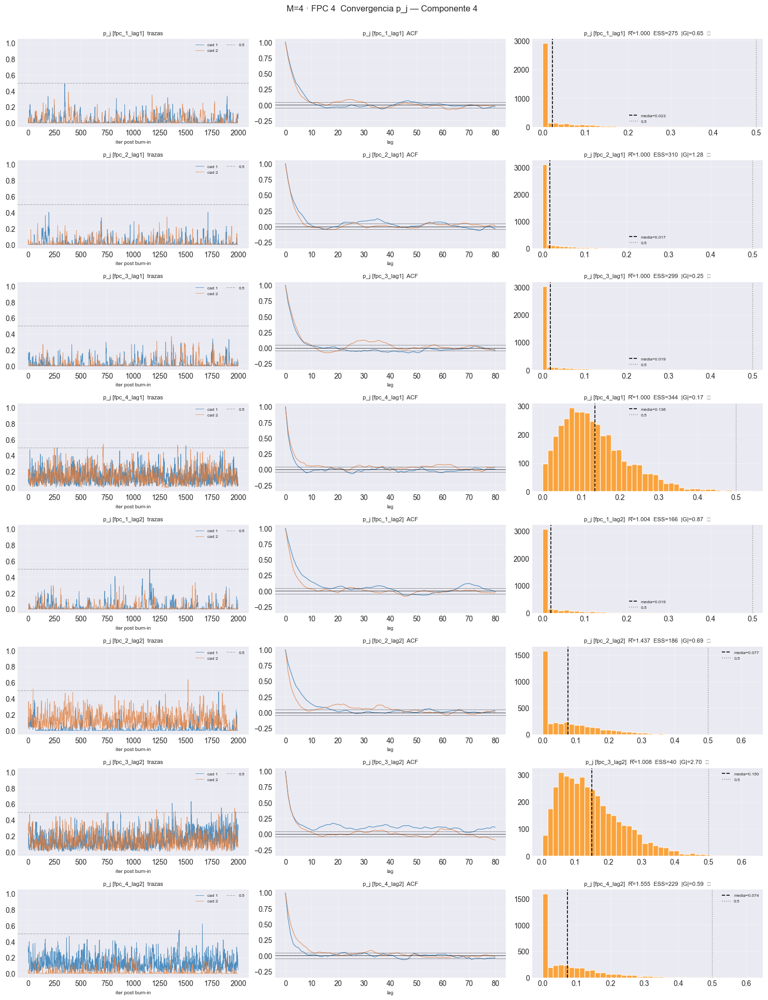

In [ ]:
# Traza | ACF | posterior, con las métricas anotadas. beta_j va promediado
# sobre átomos (invariante a la permutación de etiquetas).
# verbose=True saca Rhat/ESS/Geweke por covariable a la consola: son las mismas
# cifras que van en el título de cada panel, pero legibles y copiables sin
# tener que leerlas de la figura.
for M in M_OK:
    e = EST[M]
    print(f"== M={M} " + "=" * 46)
    for k in e["models_chains"]:
        fpc  = e["component_idx"][k] + 1
        feat = e["models_chains"][k][0].feature_names_
        plot_convergence_bj(
            e["models_chains"], k, e["burn"], e["n_iter"], feature_names=feat,
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"44_conv_bj_k{fpc}.png"),
            verbose=True)
        plt.show()
        plot_convergence_pj(
            e["models_chains"], k, e["burn"], e["n_iter"], feature_names=feat,
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"45_conv_pj_k{fpc}.png"),
            verbose=True)
        plt.show()

## 6. Probabilidades posteriores de inclusión

Tercer eje del diseño (`docs §03_06`): qué variables selecciona el modelo,
contra la estructura de dependencia que el generador realmente usó.


In [ ]:
for M in M_OK:
    e = EST[M]
    pip_df = matriz_pip(e["models_chains"], e["burn"],
                        component_idx=e["component_idx"], verbose=True)
    pip_df.to_csv(e["paths"]["out_report"] / "46_pip.csv")
    e["pip_df"] = pip_df

    cols_pip = [c for c in pip_df.columns if not c.endswith("_sd")]
    display(pip_df.style
        .background_gradient(subset=cols_pip, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} - P(gamma_j = 1 | datos), inclusión global, "
                     "media entre cadenas +- sd"))

    sd_cols = [c for c in pip_df.columns if c.endswith("_sd")]
    sd_max = float(pip_df[sd_cols].to_numpy().max()) if sd_cols else float("nan")
    e["pip_sd_max"] = sd_max
    print(f"[M={M}] dispersión máxima entre cadenas: {sd_max:.3f}"
          + ("   ! las cadenas discrepan sobre la selección" if sd_max > 0.15
             else "   OK las cadenas coinciden"))

[matriz_pip] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 6 variables, PIP en [0.042, 1.000]
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 6 variables, PIP en [0.038, 1.000]
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 6 variables, PIP en [0.054, 1.000]
[matriz_pip] listo: 3 pasos en 0.0s  tabla 6x6


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd
variable,,,,,,
fpc_1_lag1,1.000,0.000,0.521,0.678,0.057,0.007
fpc_2_lag1,0.057,0.017,1.000,0.000,0.072,0.033
fpc_3_lag1,0.526,0.671,0.273,0.311,1.000,0.000
fpc_1_lag2,0.417,0.421,0.059,0.010,0.081,0.010
fpc_2_lag2,0.518,0.681,0.092,0.044,0.054,0.000
fpc_3_lag2,0.042,0.005,0.038,0.004,0.058,0.015


[M=3] dispersión máxima entre cadenas: 0.681   ! las cadenas discrepan sobre la selección
[matriz_pip] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 8 variables, PIP en [0.037, 1.000]
  2/4 (50.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 8 variables, PIP en [0.046, 1.000]
  3/4 (75.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 8 variables, PIP en [0.053, 1.000]
  4/4 (100.0%) t=0.0s eta=0.0s  FPC 4: 2 cadenas, 8 variables, PIP en [0.045, 1.000]
[matriz_pip] listo: 4 pasos en 0.0s  tabla 8x8


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd,FPC 4,FPC 4_sd
variable,,,,,,,,
fpc_1_lag1,1.000,0.000,0.081,0.016,0.071,0.005,0.074,0.001
fpc_2_lag1,0.055,0.013,1.000,0.000,0.336,0.247,0.045,0.002
fpc_3_lag1,0.649,0.199,0.531,0.663,1.000,0.000,0.055,0.001
fpc_4_lag1,0.039,0.024,0.585,0.587,0.516,0.684,0.986,0.019
fpc_1_lag2,0.545,0.517,0.065,0.002,0.068,0.017,0.063,0.010
fpc_2_lag2,0.055,0.016,0.062,0.008,0.057,0.016,0.522,0.611
fpc_3_lag2,0.049,0.015,0.054,0.004,0.053,0.004,1.000,0.000
fpc_4_lag2,0.037,0.023,0.046,0.005,0.520,0.680,0.518,0.681


[M=4] dispersión máxima entre cadenas: 0.684   ! las cadenas discrepan sobre la selección


### 6.1 Contraste con la estructura del generador

El soporte verdadero sale de `internos["soporte"]` del generador: qué pares (score, rezago) entran en $E[\xi_{j,t}\mid\text{pasado}]$ —los no nulos de $A_{k,l}$ o de $f_k$ y, donde los mecanismos difieren, las covariables de $q_k$—. Es disperso, así que sensibilidad, especificidad y AUC sí son informativas. Con $M<4$ parte del soporte no existe como covariable. El PIP se calcula sobre los scores **estimados**: el contraste es directo sólo si $\psi_k\approx\varphi_k$ (§6.1 imprime $|\cos(\psi_k,\varphi_k)|$).


In [ ]:
for M in M_OK:
    e = EST[M]
    # [CONFIG] estructura verdadera: soporte[j, l-1, m] del generador (True si
    # xi_(m, t-l) entra en E[xi_(j,t) | pasado]).
    _esc = cargar_escenario(str(e["paths"]["raw"] / f"escenario_{ESCENARIO_ID}.npz"))
    _sop = _esc["interno_soporte"]
    VERDAD = {f"FPC {e['component_idx'][k] + 1}": [
                  f"fpc_{m + 1}_lag{l + 1}" for l in range(e["n_lags"]) for m in range(M)
                  if _sop[e["component_idx"][k], l, m]]
              for k in range(e["n_components"])}
    # El PIP es sobre scores ESTIMADOS: el contraste es directo solo si psi_k ~ phi_k.
    _w   = pesos_trapezoidales(_esc["grilla"])
    _cos = np.abs(np.diag(cargar_fpca(e["paths"]).Psi_grid.T
                          @ (_w[:, None] * _esc["interno_Phi"][:, :M])))
    e["cos_psi_phi"] = _cos
    print(f"[M={M}] |cos(psi_k, phi_k)| = {np.round(_cos, 3)}"
          + ("   <- rotadas: contraste aproximado" if _cos.min() < 0.95 else ""))

    contraste = contraste_con_verdad(e["pip_df"], VERDAD, umbral=0.5)
    e["contraste"] = contraste
    if not contraste.empty:
        contraste.to_csv(e["paths"]["out_report"] / "47_contraste_pip.csv")
        display(contraste.style.format("{:.3f}", subset=[
            c for c in contraste.columns if contraste[c].dtype.kind == "f"])
            .set_caption(f"M={M} - selección de variables vs soporte del "
                         "generador (umbral 0.5)"))


[M=3] |cos(psi_k, phi_k)| = [0.99  0.988 0.996]


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,3,1,2,2,1,0.333,0.333,0.333,0.556,0.491,0.362
FPC 2,3,2,0,1,3,0.667,1.000,0.833,0.778,0.527,0.134
FPC 3,4,1,0,3,2,0.250,1.000,0.500,0.875,0.302,0.056


[M=4] |cos(psi_k, phi_k)| = [0.99  0.988 0.996 0.992]


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,3,2,1,1,4,0.667,0.800,0.750,0.800,0.533,0.166
FPC 2,3,1,2,2,3,0.333,0.600,0.500,0.733,0.382,0.256
FPC 3,4,1,2,3,2,0.250,0.500,0.375,0.625,0.369,0.287
FPC 4,5,2,2,3,1,0.400,0.333,0.375,0.533,0.434,0.365


## 7. Verificación muestreador ↔ predictor

`inEout` es $E[y\mid x]$ dentro de muestra tal como la calcula MATLAB en cada
iteración. Debe coincidir con lo que el predictor de Python reconstruye a
partir de las mismas trazas. Es la única prueba directa de que ambos lados
interpretan las trazas igual, y falla ruidosamente si el contrato se rompe.

Se corre **en cada $M$**: el contrato depende de $p$, y el punto $M=1$ es
justamente donde MATLAB colapsa la dimensión de covariables al guardar.

In [ ]:
print("corr(inEout, predict) sobre el bloque de entrenamiento:")
ok_global = True
for M in M_OK:
    e = EST[M]
    ok = True
    print(f"-- M={M} --")
    for k in e["models_chains"]:
        for c in sorted(e["models_chains"][k]):
            m = e["models_chains"][k][c]
            mu_tr = m.predict(e["dfs_train"][k])
            inE   = m.traces["inEout"][m.burn:].mean(axis=0)
            corr  = float(np.corrcoef(inE, mu_tr)[0, 1])
            dif   = float(np.abs(inE - mu_tr).max())
            ok &= corr > 0.999
            print(f"  FPC {e['component_idx'][k]+1} cadena{c+1}: corr={corr:.6f}  "
                  f"|dif|max={dif:.4f}" + ("" if corr > 0.999 else "   ! REVISAR"))
    e["contrato_ok"] = ok
    ok_global &= ok
    print(f"  {'OK' if ok else 'X'} contrato sampler<->predictor "
          f"{'verificado' if ok else 'FALLA'} en M={M}")

print(f"\n{'OK contrato verificado en todo el barrido' if ok_global else 'X el contrato falla'}")

corr(inEout, predict) sobre el bloque de entrenamiento:
-- M=3 --
  FPC 1 cadena1: corr=1.000000  |dif|max=0.0001
  FPC 1 cadena2: corr=1.000000  |dif|max=0.0002
  FPC 2 cadena1: corr=1.000000  |dif|max=0.0001
  FPC 2 cadena2: corr=1.000000  |dif|max=0.0001


## 8. Comparación entre los puntos del barrido

| Cifra | Por qué es comparable entre $M$ |
|---|---|
| $\hat R$ máx, ESS mín, Geweke máx | son el **peor caso** sobre las variables de ese punto, no un promedio sobre un número de variables que cambia con $M$ |
| ocupación media de la mezcla | cuenta átomos, no depende de la dimensión |
| PIP media sobre las activas | proporción, acotada en $[0,1]$ |

In [ ]:
filas = []
for M in M_OK:
    e   = EST[M]
    res = e["res_conv"]
    ocu = e["ocup_df"]
    con = e["contraste"]

    fila = {
        "M": M,
        "experiment_id": e["eid"],
        "p_covariables": len(e["cov_por_componente"][0]),
        "n_variables_diag": int(res["n_variables"]),
        "rhat_max": float(res["rhat_max"]),
        "ess_min": float(res["ess_min"]),
        "geweke_max": float(res["geweke_max"]),
        "n_no_converge": int(res["n_no_converge"]),
        "converge": bool(res["todo_converge"]),
        "ocupacion_media": float(ocu["media"].mean()),
        "ocupacion_max": int(ocu["max"].max()),
        "N_trunc": int(ocu["N_trunc"].iloc[0]),
        "toca_truncamiento": bool(ocu["toca_truncamiento"].any()),
        "pip_sd_max": e["pip_sd_max"],
        "contrato_ok": bool(e["contrato_ok"]),
    }
    # `contraste_con_verdad` devuelve una fila por componente FPCA; se promedia
    # sobre componentes para tener UNA cifra por punto del barrido.
    if con is not None and not con.empty and "pip_media_activas" in con.columns:
        fila["pip_media_activas"] = float(con["pip_media_activas"].mean())
    filas.append(fila)

barrido_df = pd.DataFrame(filas).set_index("M")
barrido_df.to_csv(PATH_BARRIDO / "80_convergencia_por_M.csv")

_fmt = {c: "{:.4f}" for c in ("rhat_max", "geweke_max", "pip_sd_max",
                              "pip_media_activas") if c in barrido_df.columns}
_fmt.update({"ess_min": "{:.0f}", "ocupacion_media": "{:.2f}"})
display(barrido_df.style.format(_fmt, na_rep="-")
        .background_gradient(subset=["rhat_max"], cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn", vmin=0, vmax=500)
        .set_caption("Diagnóstico de muestreo a lo largo del barrido en M"))

In [ ]:
# Figura del barrido: cuatro paneles, todos con M en el eje x. Los umbrales van
# como línea horizontal para que la lectura no dependa de recordar cuáles son.
_Ms = list(barrido_df.index)
_um = EST[M_OK[0]]["res_conv"]["umbrales"]

paneles = [
    ("rhat_max",        "Rhat máximo",            _um["rhat"],   "menor es mejor"),
    ("ess_min",         "ESS mínimo",             _um["ess"],    "mayor es mejor"),
    ("geweke_max",      "|Geweke| máximo",        _um["geweke"], "menor es mejor"),
    ("ocupacion_media", "átomos ocupados (med.)", None,          "descriptivo"),
]

fig, axes = plt.subplots(1, len(paneles), figsize=(4.0 * len(paneles), 3.4),
                         squeeze=False)
for ax, (col, titulo, umbral, nota) in zip(axes[0], paneles):
    y = barrido_df[col].to_numpy(dtype=float)
    ax.plot(_Ms, y, "o-", lw=1.8, ms=7, color="#2c7fb8")
    if umbral is not None:
        ax.axhline(umbral, color="#c0392b", ls="--", lw=1.2,
                   label=f"umbral {umbral}")
        ax.legend(fontsize=8)
    if col == "ocupacion_media":
        ax.axhline(barrido_df["N_trunc"].iloc[0], color="#c0392b", ls=":", lw=1.2)
    ax.set_xticks(_Ms)
    ax.set_xlabel("M (componentes FPCA)")
    ax.set_title(f"{titulo}\n({nota})", fontsize=10)
fig.suptitle(f"{EXPERIMENT_BASE} - diagnóstico de muestreo vs M", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "81_diagnostico_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Ocupación de la mezcla por M y componente: es la cifra que dice si al subir M
# el modelo parte la mezcla en más átomos. Se separa por FPC porque el promedio
# global esconde que sean las componentes NUEVAS las que se fragmentan.
ocup_todo = pd.concat([EST[M]["ocup_df"] for M in M_OK], ignore_index=True)
ocup_todo.to_csv(PATH_BARRIDO / "82_ocupacion_por_M.csv", index=False)

piv = ocup_todo.groupby(["M", "FPC"])["media"].mean().unstack("FPC")
display(piv.style.format("{:.2f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("Átomos ocupados (media post-burn) por M y componente FPCA"))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
for fpc in piv.columns:
    s = piv[fpc].dropna()
    ax.plot(s.index, s.to_numpy(), "o-", lw=1.6, ms=6, label=f"FPC {int(fpc)}")
_Ntr = int(ocup_todo["N_trunc"].iloc[0])
ax.axhline(_Ntr, color="#c0392b", ls=":", lw=1.2, label=f"truncamiento N={_Ntr}")
ax.set_xticks(list(piv.index))
ax.set_xlabel("M (componentes FPCA)")
ax.set_ylabel("átomos ocupados (media post-burn)")
ax.set_title("Fragmentación de la mezcla a lo largo del barrido")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "82_ocupacion_por_M.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# PIP: una fila por (M, componente FPCA, covariable). Las matrices de distintos
# M no se apilan tal cual porque no comparten ni filas ni columnas, así que se
# pasan a formato largo, que sí admite la comparación.
partes = []
for M in M_OK:
    pip  = EST[M]["pip_df"]
    cols = [c for c in pip.columns if not c.endswith("_sd")]
    largo = pip[cols].stack().rename("pip").reset_index()
    largo.columns = ["covariable", "componente", "pip"]
    largo.insert(0, "M", M)
    partes.append(largo)

pip_largo = pd.concat(partes, ignore_index=True)
pip_largo.to_csv(PATH_BARRIDO / "83_pip_por_M.csv", index=False)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for cov, g in pip_largo.groupby("covariable"):
    s = g.groupby("M")["pip"].mean()
    ax.plot(s.index, s.to_numpy(), "o-", lw=1.5, ms=6, label=str(cov))
ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.6, label="umbral 0.5")
ax.set_xticks(list(M_OK))
ax.set_ylim(0, 1.02)
ax.set_xlabel("M (componentes FPCA)")
ax.set_ylabel("PIP global (media sobre componentes)")
ax.set_title("Probabilidad de inclusión por covariable a lo largo del barrido\n"
             "una covariable presente en todos los M debería mantener su PIP",
             fontsize=10)
ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "83_pip_por_M.png", dpi=150, bbox_inches="tight")
plt.show()

print("Las covariables que sólo existen a partir de cierto M aparecen con la "
      "línea cortada: no es un hueco de datos, es que esa covariable no existe "
      "en los puntos más chicos del barrido.")

In [ ]:
# == Veredicto del barrido ===================================================
print("=" * 66)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {list(M_OK)}")
print("=" * 66)
for M in M_OK:
    f = barrido_df.loc[M]
    print(f"  M={M}  p={int(f['p_covariables'])}  "
          f"Rhatmax={f['rhat_max']:.3f}  ESSmin={f['ess_min']:.0f}  "
          f"ocup={f['ocupacion_media']:.1f}/{int(f['N_trunc'])}  "
          f"{'OK' if f['converge'] else 'X NO CONVERGE'}")

_no   = [int(M) for M in barrido_df.index if not barrido_df.loc[M, "converge"]]
_falt = sorted(set(M_FPCA_LIST) - set(M_OK))
print("-" * 66)
if _falt:
    print(f"! sin trazas todavía: M = {_falt}  -> correr psbp_fd_iteracion.m")
if _no:
    print(f"X NO convergen: M = {_no}. Excluirlos de la comparación de 107_04/107_05,")
    print("  o subir nsim/burn antes de leer su MISE como efecto de M.")
else:
    print("OK todo el barrido converge: las diferencias que 107_04 encuentre entre")
    print("   los M son atribuibles al modelo y no al muestreo.")

# Tendencia, sólo con al menos tres puntos: con dos, cualquier par define una
# recta y la pendiente no dice nada.
if len(M_OK) >= 3:
    _r = np.corrcoef(list(M_OK), barrido_df["rhat_max"].to_numpy())[0, 1]
    _e = np.corrcoef(list(M_OK), barrido_df["ess_min"].to_numpy())[0, 1]
    print(f"\ncorr(M, Rhatmax) = {_r:+.3f}   ·   corr(M, ESSmin) = {_e:+.3f}")
    if _r > 0.8 or _e < -0.8:
        print("  <- el muestreo se degrada monótonamente con M: parte de lo que")
        print("     107_04 atribuya a M sería esfuerzo de muestreo insuficiente.")
print("=" * 66)
print(f"Tablas y figuras cruzadas en {PATH_BARRIDO}  (archivos 80-83)")
print("Continuar con 107_04_evaluacion, declarando el mismo M_FPCA_LIST.")